# jval_lab — interventional unmixing on the jval_* worlds

Section 7 of the v2 handoff, executed. Nothing re-simulates: every arm is an
analysis window or a Jacobian rebuilt from a few hundred zero-duration solves.

**How to read this notebook.** It is organised as one section per experiment.
Each opens with the question it answers, why that question is open, and what
decides it. Each closes with a small **answer table** — question, statistic,
value, verdict, and the rule that produced the verdict — followed by the raw
tables for sanity checking. Every threshold lives in `J.THRESH`, so no verdict
is a sentence someone typed. §17 collects the answers into one sheet.

---

## 1. What is being computed

**Setup.** $n{=}113$ junctions partitioned into $K{=}5$ districts
$\mathcal{N}_1,\dots,\mathcal{N}_K$, observed through $m{=}15$ flow sensors.
$d\in\mathbb{R}^n$ is nodal demand, $y\in\mathbb{R}^m$ sensor readings.

**Why observing is not estimating.** Steady flow linearised about an operating
point gives $L\,\mathrm{d}H = \mathrm{d}d$ with $L = A^\top G A$, $A$ the
node–arc incidence matrix and
$g_{ij} = 1/\big(\kappa\,r_{ij}|Q_{ij}|^{\kappa-1}\big)$, $\kappa\approx1.85$.
$L$ is a weighted graph Laplacian, hence symmetric, hence $L^{+}$ is symmetric
— so $\partial H_j/\partial d_i = \partial H_i/\partial d_j$ *exactly*.
Pressure sensitivity has no antisymmetric part and can never carry
orientation; direction must come from flow, which is a routing matrix and
manifestly asymmetric. A theorem, not an empirical regularity.

Locally, $y = Jd + c$. Correlation is **not** preserved under this map:
$\rho(y_a,y_b) \neq \rho(d_a,d_b)$ in general. No choice of *which* mixed
signal to observe repairs that — the mixing must be inverted. That single fact
is the mechanism behind the whole preceding sequence of negative results
(sector tests, drift attribution, Granger direction).

**Stage 1 — measure $J$ by intervention.** At a flat baseline (demands
constant, `duration=0`, one steady-state solve, so the answer is a Jacobian and
not a dynamic response), perturb each junction individually:

$$\hat J_{si} \;=\; \frac{y_s(d^{0}+\delta e_i)-y_s(d^{0})}{\delta}.$$

Additive, not multiplicative, so magnitudes stay comparable across nodes and
the many zero-demand junctions are still probed. $\delta = 0.5\,\bar d$,
$\bar d = \frac1n\sum_i d^0_i$ over *all* junctions including zeros — chosen by
minimising reciprocity asymmetry, a criterion anchored to the theorem above
rather than to any downstream metric.

**Stage 2 — aggregate to districts.** Node-level inversion is hopeless
($15$ sensors, $113$ nodes); district aggregation makes it overdetermined
($15\times5$). With $w_k \ge 0$, $\mathbf1^\top w_k = 1$ the within-district
demand shares,

$$J^{\mathrm d}_{:,k} = \hat J_{:,\mathcal N_k} w_k,
\qquad
y_t = J^{\mathrm d} D_t + c \;\;\text{ iff }\;\;
d_{i,t} = D_{k,t}\,w_{k,i}\;\;\forall i\in\mathcal N_k,$$

$D_{k,t}=\sum_{i\in\mathcal N_k} d_{i,t}$. That proportionality is the one real
modelling commitment — and exactly what a mid-conversion district violates
(§16).

**Stage 3 — unmix.** Least squares on deviations, so the static operating point
drops out:

$$\hat D_t = \big(J^{\mathrm d}\big)^{+}(y_t-\bar y),
\qquad
\|\hat D-D\| \lesssim \frac{\|\Delta J^{\mathrm d}\|}{\sigma_{\min}(J^{\mathrm d})}\|D\|.$$

Error scales as $1/\sigma_{\min}$, which makes **optimal experiment design the
natural placement objective** — better founded than AUROC-against-adjacency or
decoupling. Dependence statistics are computed on $\hat D$, never on $y$.

## 2. The two measurands (7.2), deliberately orthogonal

| | **M1 — structure** | **M2 — level** |
|---|---|---|
| statistic | $\mathrm{MAE}=\binom K2^{-1}\sum_{a<b}\lvert\rho(\hat D_a,\hat D_b)-\rho(D_a,D_b)\rvert$; Spearman over the 10 pairs; gap retention $\hat G/G$, $G=\bar\rho_{\text{same}}-\bar\rho_{\text{diff}}$ | $r_k=\log\dfrac{\operatorname{sd}(\hat D_k)}{\operatorname{sd}(D_k)}$; report $\operatorname{sd}_k(r_k)$ and $\operatorname{Spearman}_k(\operatorname{sd}\hat D_k,\operatorname{sd}D_k)$ |
| reads | land use (shape) | income (amplitude) |
| blind to | amplitude — Pearson is scale-invariant, so M1 **cannot** see income | shape |
| caveat | on the income arm M1 is a *null control*: movement is method error | $J^{\mathrm d}$ carries a global scale factor, so $\bar r$ is unidentifiable and diagnostic only |

## 3. Windows and arms

$\text{pre}=$ months 0–5, $\text{transition}=$ 6–35, $\text{post}=$ 36–41.
Equal length (4 320 steps) so the two correlation estimators have identical
variance; $36\equiv0\pmod{12}$ so pre and post cover the same calendar months
and the seasonal cycle *cancels* rather than merely matching.

Topology never changes under drift — only demands. So $J^{\mathrm d}$ can move
only through the **operating point** $d^0$ and the **composition** $w_k$, and
those are separable for a few hundred solves:

| arm | probe point $d^0$ | weights $w_k$ | isolates |
|---|---|---|---|
| `J_inp` | base demands $\times$ `anchor_scale` | .inp proportions | the section-5 baseline |
| `J_pre` | pre-window mean | pre-window shares | commissioning-time $J$ |
| `J_post` | post-window mean | post-window shares | recommissioned $J$ |
| `J_pre_wpost` | pre-window mean | **post**-window shares | composition alone |
| `J_perm` | pre-window mean | pre shares, **columns shuffled** | falsification — must collapse |

`J_pre_wpost` $-$ `J_pre` is the composition term; `J_post` $-$ `J_pre_wpost`
the operating-point term.

## 4. Corrections in this revision

1. **`anchor_scale` forwarded to `flat_baseline`** — its default is `1.0` while
   the worlds are built at `0.05`, so the previous run probed `J_inp` at
   $20\times$ the world's demand ($5.56$ vs $0.28$ m³/s), every solve came back
   infeasible at $-865$ mca, and the sweep was silently emptied. `J_inp` is
   back in the default arms.
2. **Arms matched against the design, not inferred from the spec** — the
   rule-based labeller swept in foreign 48-month worlds: 20 tagged `s1_oddone`
   against a design of 15, five of them contaminating the `beta` arm.
3. **P6 scored on the matched cell** with the operating-point excursion
   attached, so a flat result reads as *underpowered* rather than as evidence
   against the mechanism.
4. **P5 decomposed** into its estimator and baseline terms — a gain is a
   difference, and the previous run's movement was entirely in the second.
5. **Probes hoisted out of the placement loop** — five placements now cost one
   world's hydraulics.

In [1]:
import sys, pathlib, copy
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import wntr, yaml

HERE = pathlib.Path.cwd().resolve()
PROJ = next((p for p in [HERE, *HERE.parents] if (p / "pyproject.toml").exists()), HERE)
for p in (PROJ / "src", PROJ / "notebooks", PROJ, HERE):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

In [2]:
# =====================================================================
# 0. setup
# =====================================================================
import sys, pathlib, json, warnings
import numpy as np, pandas as pd, yaml
from scipy import stats as sps
import matplotlib.pyplot as plt

PROJ = pathlib.Path.home() / "USPy/10_Mestrado/fedWater"      # <-- adjust
sys.path.insert(0, str(PROJ / "notebooks" / "SensorPlacement"))

import placement_poc as P
import sensitivity_probe as S
import jval_engine as J

OUT = PROJ / "data/08_reporting/jval"; OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 150)

PLACEMENT   = "variance"       # deployment recommendation (handoff 5.1)
MAIN_ARM    = "J_pre"          # commissioning-time J -- the Q2 protagonist
DELTA_FRAC  = 0.5              # reciprocity-calibrated step (handoff 4)
RCOND       = 1e-3
PINNED_MAE  = 0.052            # section 5's headline, for reference only
ARMS        = J.ARMS_DEFAULT   # J_inp / J_pre / J_post / J_pre_wpost / J_perm
PLACE_NAMES = J.PLACEMENTS_ALL # variance / boundary / manual / spread / random

LEDGER = J.Ledger()            # every answer lands here; rendered in section 17

J.api_report()                 # fails loudly if a borrowed signature drifted
J.selftest()                   # measurands checked against known answers
print("\ndecision thresholds:", J.THRESH)

           module               name                                                                                                                                               signature
sensitivity_probe      flat_baseline                    (wn, anchor_scale: 'float' = 1.0, demand_model: 'str' = 'DD', min_pressure: 'float | None' = None, demand_multiplier: 'float' = 1.0)
sensitivity_probe perturbation_sweep                                                                 (wn_flat, deltas, nodes=None, verbose=False, drop_infeasible: 'bool' = True) -> 'tuple'
sensitivity_probe           jacobian                                                                (sweep: 'pd.DataFrame', quantity='pressure', delta=None, targets=None) -> 'pd.DataFrame'
sensitivity_probe  district_jacobian (sweep: 'pd.DataFrame', districts: 'dict', sensors: 'list', quantity='flowrate', delta=None, node_weights: 'pd.Series | None' = None) -> 'pd.DataFrame'
sensitivity_probe      unmix_demands                   

## 5. E1 — Did we build the design, and only the design?

**Question.** Do the worlds on disk correspond one-to-one with the cells in
`experiments_jval.yml`, and are any foreign worlds being pulled into the arms?

**Why it is open.** `data/09_experiments/worlds/` is a content-addressed pool
that grows as studies run, and other studies also use `n_months = 48`. The
manifest's `world` block does not expose `warmup_months`, so two worlds can
look identical on every field a labeller can see while being built under
different warmups. Inferring the arm from the spec therefore over-collects:
the previous run labelled 20 worlds `s1_oddone` against a design of 15, and the
extras landed in the `beta` arm, where they were compared against
single-world $\beta$ cells.

**What decides it.** `design_table()` is the yml transcribed — 40 unique cells,
three of them serving two studies (`jval_coupling`'s baseline arm and
`jval_beta`'s $\beta{=}0.35$ cell *are* `jval_s1_oddone` worlds, deliberate
cache hits). `label_arms` matches cell by cell, marks anything unmatched as
`other`, marks a second claimant on a cell as `dup`, and re-checks
`onset == warmup_months == 6`. `design_audit` is the count check the previous
run lacked.

In [3]:
# =====================================================================
# E1. inventory: discover -> gate -> match design -> pin
# =====================================================================
IDX = J.jval_index(PROJ, n_months=48)


def _districts():
    for c in (PROJ / "data/01_raw/districts_graeme.yml",
              pathlib.Path(IDX.iloc[0]["dir"]) / "clone/data/01_raw/districts_graeme.yml"):
        if c.exists():
            return yaml.safe_load(c.read_text())
    return P.load_world(IDX.iloc[0]["dir"])["districts"]
DISTRICTS = _districts()
DS = sorted(DISTRICTS["districts"])

GATES = J.gate_table(IDX, DISTRICTS)
LAB = J.label_arms(IDX, onset=GATES.set_index("sim_hash")["onset"])
GATES = GATES.drop(columns=[c for c in ("arm",) if c in GATES.columns]).merge(
    LAB[["sim_hash", "cell", "arm", "studies", "dup"]], on="sim_hash", how="left")
WORLDS = J.pin(LAB, GATES, path=OUT / "pinned_worlds.csv")

ANS = J.answer_inventory(LAB, WORLDS); LEDGER.extend(ANS); display(ANS)

,exp,question,metric,value,answer,basis
0,E1,"Did we build the design, and only the design?",studies complete / total,3/5,NO -- arms incomplete,design_table() cell-by-cell match
1,E1,How many 48-month worlds are foreign to the design?,unmatched + duplicate-cell,1 + 4,5 excluded,arm=='other' or dup=True; rule-based labelling had swept these in
2,E1,How many worlds carry the analysis?,pinned,40,"40 worlds, 5 arms",gate 7.7 passed AND design-matched AND not duplicate


In [4]:
# --- sanity ---------------------------------------------------------------
print(f"{len(IDX)} worlds at n_months=48 | usable {int(IDX.usable.sum())} | "
      f"district sizes {[len(DISTRICTS['districts'][d]) for d in DS]}")
print("anchor_scale in manifest:", "anchor_scale" in IDX.columns,
      sorted(IDX.anchor_scale.unique()) if "anchor_scale" in IDX.columns else "")
display(J.design_audit(LAB))
display(LAB[["sim_hash", "arm", "studies", "cell", "dup", "onset"]])
print(f"pinned {len(WORLDS)} -> {OUT/'pinned_worlds.csv'}")
print(WORLDS.groupby("arm").size().to_string())

45 worlds at n_months=48 | usable 45 | district sizes [12, 29, 18, 24, 30]
anchor_scale in manifest: True [0.05]


,study,designed,matched,duplicates,complete
0,s1_oddone,15,16,4,False
1,s2_split,15,15,0,True
2,income,6,6,0,True
3,beta,3,4,1,False
4,coupling,4,4,1,True
5,(unmatched),0,1,0,True


,sim_hash,arm,studies,cell,dup,onset
0,2f848af2d6ac,beta,beta,LR_LR_LR_LR_LI|baseline|b0.00|s42|Dli,False,6.0
1,7c18c548fcc4,beta,"beta,s1_oddone",LR_LR_LR_LR_LI|baseline|b0.35|s42|Dli,False,6.0
2,d1683cdf79d8,beta,"beta,s1_oddone",LR_LR_LR_LR_LI|baseline|b0.35|s42|Dli,True,6.0
3,4ffa4bda4b5c,beta,beta,LR_LR_LR_LR_LI|baseline|b1.00|s42|Dli,False,6.0
4,74e5d158e6e7,coupling,"coupling,s1_oddone",LR_LR_LR_LR_LI|baseline|b0.35|s42|Ali,False,6.0
5,adfe1b1ae73a,coupling,"coupling,s1_oddone",LR_LR_LR_LR_LI|baseline|b0.35|s42|Elr,False,6.0
6,fbd240dac636,coupling,"coupling,s1_oddone",LR_LR_LR_LR_LI|baseline|b0.35|s42|Elr,True,6.0
7,b472a1a6af0b,coupling,coupling,LR_LR_LR_LR_LI|isolated|b0.35|s42|Ali,False,6.0
8,adce256d7a30,coupling,coupling,LR_LR_LR_LR_LI|isolated|b0.35|s42|Elr,False,6.0
9,262eba17b212,income,income,LR_LR_LR_LR_HR|baseline|b0.35|s42|Chr,False,6.0


pinned 40 -> C:\Users\arthu\USPy\10_Mestrado\fedWater\data\08_reporting\jval\pinned_worlds.csv
arm
beta          3
coupling      4
income        6
s1_oddone    12
s2_split     15


## 6. E2 — Is every world individually usable?

**Question.** Did the drift front complete, did it finish before the post
window opens, and is the pre window uncontaminated?

**Why it is open.** The conversion front advances stochastically
(`growth_chance = 0.8`, `max_neighbors_per_month = 2`), so span is a random
variable even though onset is not. A world whose front is still advancing at
month 36 has a post window that is neither pre-drift nor post-drift, and every
windowed statistic computed on it is meaningless. This already happened once:
the `resolution_probe` worlds converted 5 of 24 nodes with the 42-day ramp
clamped to 29 days, and a finer-resolution conclusion was drawn on them.

**What decides it.** Three assertions (handoff 7.7), evaluated as *rows* rather
than raised, so a failure is documented and excluded rather than aborting the
sweep: `len(sch) == n_nodes[tgt]`, `sch.drift_month.max() + 1.4 < 36`,
`sch.drift_month.min() >= 6`.

In [5]:
# =====================================================================
# E2. the three per-world assertions
# =====================================================================
bad = GATES[~GATES.ok]
LEDGER.add("E2", "Did every world's drift front complete inside the horizon?",
           "worlds failing the 7.7 gate", int(len(bad)),
           "YES -- all pass" if not len(bad) else f"NO -- {len(bad)} excluded",
           "front_complete AND clears_post AND pre_clean")
display(LEDGER.frame().tail(1))

,exp,question,metric,value,answer,basis
3,E2,Did every world's drift front complete inside the horizon?,worlds failing the 7.7 gate,0,YES -- all pass,front_complete AND clears_post AND pre_clean


In [6]:
# --- sanity ---------------------------------------------------------------
display(GATES[["sim_hash", "arm", "tgt", "n_nodes", "n_converted", "onset",
               "last", "span", "front_complete", "clears_post", "pre_clean",
               "ok", "why"]])
if len(bad):
    print(bad.groupby("why").size().to_string())
print("span by target district (deterministic in size, stochastic in advance):")
print(GATES.groupby("tgt")[["n_nodes", "span"]].agg(["mean", "min", "max"])
      .round(1).to_string())

,sim_hash,arm,tgt,n_nodes,n_converted,onset,last,span,front_complete,clears_post,pre_clean,ok,why
0,321c58788a66,s2_split,District_A,12,12,6.0,14.0,8.0,True,True,True,True,
1,4b080c673115,s2_split,District_A,12,12,6.0,14.0,8.0,True,True,True,True,
2,299af99e87ec,s2_split,District_A,12,12,6.0,14.0,8.0,True,True,True,True,
3,587505ee4003,s2_split,District_B,29,29,6.0,24.0,18.0,True,True,True,True,
4,f4be1b00824a,s2_split,District_B,29,29,6.0,25.0,19.0,True,True,True,True,
5,2b87569fdb9c,s2_split,District_B,29,29,6.0,22.0,16.0,True,True,True,True,
6,b1bd9a062e70,s2_split,District_C,18,18,6.0,16.0,10.0,True,True,True,True,
7,0ef702709d16,s2_split,District_C,18,18,6.0,19.0,13.0,True,True,True,True,
8,86aac0246743,s2_split,District_C,18,18,6.0,19.0,13.0,True,True,True,True,
9,1002d903396d,s2_split,District_D,24,24,6.0,23.0,17.0,True,True,True,True,


span by target district (deterministic in size, stochastic in advance):
           n_nodes          span            
              mean min max  mean   min   max
tgt                                         
District_A    12.0  12  12   8.0   8.0   8.0
District_B    29.0  29  29  16.3   8.0  19.0
District_C    18.0  18  18  11.5   7.0  13.0
District_D    24.0  24  24  15.6  11.0  17.0
District_E    30.0  30  30  18.5   9.0  20.0


## 7. E3 — Are the windows comparable?

**Question.** Do `pre` and `post` have identical step counts and cover the same
calendar months?

**Why it is open.** A pre$\to$post *difference* is the estimand for P3 and P4.
If the two windows have different lengths, the two correlation estimators have
different variance and part of any difference is an estimator artifact. If they
cover different calendar months, the seasonal cycle contributes a real but
irrelevant difference.

**What decides it.** 4 320 steps each, and $36 \equiv 0 \pmod{12}$ so the
seasonal cycle *cancels* rather than merely matching. Both asserted.

In [7]:
# =====================================================================
# E3. window comparability
# =====================================================================
rows = []
for arm, g in WORLDS.groupby("arm"):
    w = g.iloc[0]
    dem = pd.read_parquet(pathlib.Path(w["dir"]) / J.PATHS["demand"])
    mo = J.month_vector({"steps_day": 24}, dem, len(dem))
    rows.append(dict(arm=arm, sim_hash=w["sim_hash"], n_rows=len(dem),
                     months=int(mo.max()) + 1,
                     **J.window_report(J.window_masks(mo))))
WR = pd.DataFrame(rows)
assert WR.pre_eq_post.all() and (WR.pre == 4320).all(), WR
LEDGER.add("E3", "Are the pre and post windows comparable?",
           "equal length AND same calendar months", "4320 / 4320, 36 mod 12 = 0",
           "YES", "equal variance for the two estimators; seasonal cycle cancels")
display(LEDGER.frame().tail(1)); display(WR)

,exp,question,metric,value,answer,basis
4,E3,Are the pre and post windows comparable?,equal length AND same calendar months,"4320 / 4320, 36 mod 12 = 0",YES,equal variance for the two estimators; seasonal cycle cancels


,arm,sim_hash,n_rows,months,pre,transition,post,pre_eq_post
0,beta,2f848af2d6ac,34560,48,4320,21600,4320,True
1,coupling,74e5d158e6e7,34560,48,4320,21600,4320,True
2,income,262eba17b212,34560,48,4320,21600,4320,True
3,s1_oddone,72066814f9c1,34560,48,4320,21600,4320,True
4,s2_split,321c58788a66,34560,48,4320,21600,4320,True


## 8. E4 — Are P3 and P4 scoreable at all, and how demanding are they?

**Question.** Does the ground truth actually exhibit the invariance and the
signed change that P3 and P4 ask the estimator to reproduce, and how large is
the effect being detected?

**Why it is open.** P3 says "$\rho(A,B)$ is unchanged when D drifts, so any
movement in $\hat\rho$ is pure method error." P4 says "$\rho(D,E)$ must rise."
Both are asserted *by construction* — but the construction is a claim about the
simulator, and the demand series carries seasonal and stochastic variation on
top of it. If $\rho_{\text{true}}(A,B)$ itself moves by $0.05$ pre$\to$post
then P3's threshold of $0.02$ is not a null and a P3 "failure" is measuring the
simulator. Symmetrically, if the truth does not move in the predicted
direction, a P4 failure indicts the prediction or `state_map`, not the
unmixing.

**What decides it.** Recompute both statistics on the demand series alone — no
hydraulics, seconds per world. The non-drifter $\lvert\Delta\rho_{\text{true}}
\rvert$ p95 becomes P3's empirical floor; truth sign agreement becomes P4's
ceiling. The spread of $G_{\text{true}}$ across worlds says how demanding the
gap test is: a near-constant $G$ means the demand model makes shape similarity
an almost deterministic function of the land-use token, so passing is cheap and
should be reported as such.

In [8]:
# =====================================================================
# E4. ground-truth audit -- before any estimator is scored
# =====================================================================
TA = J.truth_audit(WORLDS, DISTRICTS)
DT = J.delta_rho(TA, method="truth", placement="truth")
FLOOR = float(max(J.THRESH["mae_negligible"],
                  DT.loc[~DT.involves_drifter, "d_true"].abs().quantile(.95)))

ANS = J.answer_truth(DT, TA, FLOOR); LEDGER.extend(ANS); display(ANS)

  10/40
  20/40
  30/40
  40/40


,exp,question,metric,value,answer,basis
0,E4,Is the invariance null clean enough in the TRUTH to score P3?,"mean |d rho_true|, non-drifter pairs",0.001198,YES,threshold 0.02; P3 floor set to 0.0200
1,E4,Does the intervention move the truth in the predicted direction?,sign agreement in truth (P4 ceiling),1.000000,YES,ceiling for P4; threshold 0.9
2,E4,How demanding is the gap test?,effect size |d rho_true|,0.720128,large,"sd(G_true) across worlds = 0.0012; near-zero means G is an almost deterministic function of the land-use token, so passing the gap test is cheap"


In [9]:
# --- sanity ---------------------------------------------------------------
def sign_hit(g, col):
    q = g[g.predicted != 0]
    return np.nan if not len(q) else float((np.sign(q[col]) == q.predicted).mean())

display(pd.DataFrame([dict(
    arm=a, n=len(g),
    invariance_true=g.loc[~g.involves_drifter, "d_true"].abs().mean(),
    signed_true=sign_hit(g, "d_true"))
    for a, g in DT.groupby("arm_study")]).round(4))
display(DT[DT.predicted != 0].groupby("predicted")["d_true"]
        .agg(["mean", "std", "size"]).round(4))
for win in ("pre", "post"):
    q = TA[TA.window == win]
    g = pd.Series({h: (x.loc[x.state_a == x.state_b, "rho_true"].mean() -
                       x.loc[x.state_a != x.state_b, "rho_true"].mean())
                   for h, x in q.groupby("sim_hash")})
    print(f"G_true[{win:5s}] mean {g.mean():+.4f}  sd {g.std():.4f}  "
          f"n={g.notna().sum()}")

,arm,n,invariance_true,signed_true
0,beta,30,0.0012,1.0
1,coupling,40,0.0007,1.0
2,income,60,0.0004,NaN
3,s1_oddone,120,0.0013,1.0
4,s2_split,150,0.0016,1.0


,mean,std,size
predicted,,,
-1,-0.7201,0.0016,69
1,0.7202,0.0024,67


G_true[pre  ] mean +0.7193  sd 0.0012  n=34
G_true[post ] mean +0.7197  sd 0.0012  n=30


## 9. E5 — Is the Jacobian being measured at the right operating point?

**Question.** For each candidate probe point, what total demand does it imply,
and is the network feasible there?

**Why it is open.** `perturbation_sweep` drops infeasible solves **silently**.
An operating point outside the feasible envelope therefore yields an empty
sweep, an empty Jacobian, and a zero-size reduction deep inside
`unmixing_quality` — five calls from the cause. That is precisely what happened
last run: `flat_baseline`'s `anchor_scale` defaults to $1.0$ while the worlds
are built at $0.05$, so `J_inp` was probed at $20\times$ the world's demand and
the whole arm vanished. A Jacobian is only valid near the point it was
measured at, so this is not a nuisance — it is the validity condition.

**What decides it.** `probe_diag` reports total demand, mean nodal demand,
$\delta$, feasibility, baseline minimum pressure, matched sensor count and
conditioning at four candidate points, plus `x_pre_mean` — the ratio to the
pre-window mean. Near $1$ for `inp_base` means the anchor is forwarded; near
$20$ means it is not. The same table yields the pre$\to$post excursion, which
is what $\beta$ is supposed to dial (§15).

In [10]:
# =====================================================================
# E5. operating points, then one world end to end
# =====================================================================
w0 = WORLDS[WORLDS.arm == "s1_oddone"].iloc[0]
AS0 = float(w0.get("anchor_scale", 1.0) or 1.0)
art0 = P.load_world(w0["dir"])
pl0 = J.placements(art0, names=PLACE_NAMES)
dem0 = pd.read_parquet(pathlib.Path(w0["dir"]) / J.PATHS["demand"])
mk0 = J.window_masks(J.month_vector(art0, dem0, len(dem0)))
sens0 = [e for e in J.flatten(pl0[PLACEMENT]) if e in art0["flows"].columns]

PD = J.probe_diag(art0, dem0, mk0, DELTA_FRAC, DISTRICTS, sens0,
                  anchor_scale=AS0)
inp_ok = bool(PD.loc[PD.operating_point == "inp_base", "ok"].iloc[0])
xinp = float(PD.loc[PD.operating_point == "inp_base", "x_pre_mean"].iloc[0])
EXC = float(PD.loc[PD.operating_point == "post_mean", "x_pre_mean"].iloc[0])

LEDGER.add("E5", "Is the .inp-anchored probe point feasible?",
           "inp_base total / pre-window total", xinp,
           "YES" if inp_ok else "NO -- anchor_scale not forwarded",
           f"anchor_scale={AS0}; a ratio near 1/{AS0:g} means flat_baseline's "
           "default of 1.0 was used")
LEDGER.add("E5", "How far does the operating point move across the drift?",
           "post/pre total demand", EXC,
           "material" if EXC >= J.THRESH["excursion_min"] else "negligible",
           f"threshold {J.THRESH['excursion_min']}; bounds what h~Q^1.85 "
           "curvature has to act on, and therefore bounds E15")
display(LEDGER.frame().tail(2))
assert inp_ok, "inp_base infeasible -- is anchor_scale being forwarded?"

,exp,question,metric,value,answer,basis
8,E5,Is the .inp-anchored probe point feasible?,inp_base total / pre-window total,0.982,YES,anchor_scale=0.05; a ratio near 1/0.05 means flat_baseline's default of 1.0 was used
9,E5,How far does the operating point move across the drift?,post/pre total demand,1.295,material,"threshold 1.1; bounds what h~Q^1.85 curvature has to act on, and therefore bounds E15"


In [11]:
# --- sanity ---------------------------------------------------------------
print(w0[[c for c in ("sim_hash", "cell", "consumption_map", "drift_district",
                      "drift_to_land_use", "sim_seed", "beta", "variant",
                      "anchor_scale") if c in w0.index]].to_string())
print(f"\n{len(sens0)}/{len(J.flatten(pl0[PLACEMENT]))} '{PLACEMENT}' "
      f"elements present in flows.parquet | placements {sorted(pl0)}")
for k in sorted(pl0):
    print(f"  {k:9s}", {d: pl0[k][d] for d in sorted(pl0[k])})
display(PD.round(6))

r0, p0, d0g = J.run_world(w0, place_names=(PLACEMENT,), arms=ARMS,
                          delta_frac=DELTA_FRAC, rcond=RCOND, verbose=True)
display(d0g[["arm", "probe", "delta", "mean_d", "op_total", "baseline_min_p",
             "n_feasible", "n_sensors", "cond", "sigma_min"]].round(6))
display(r0.pivot_table(index="method", columns="window",
                       values=["mae", "rank_corr"]).round(4))

sim_hash                                      72066814f9c1
cell                 LR_LR_LR_LR_LI|baseline|b0.35|s42|Bli
consumption_map                             LR_LR_LR_LR_LI
drift_district                                  District_B
drift_to_land_use                               industrial
sim_seed                                                42
beta                                                  0.35
variant                                           baseline
anchor_scale                                          0.05

15/15 'variance' elements present in flows.parquet | placements ['boundary', 'manual', 'random', 'spread', 'variance']
  boundary  {'District_A': ['104', '103', '176'], 'District_B': ['136', '134', '133'], 'District_C': ['97', '95', '129'], 'District_D': ['96', '44', '69'], 'District_E': ['67', '181', '65']}
  manual    {'District_A': ['102', '100', '85'], 'District_B': ['157', '135', '165'], 'District_C': ['110', '119', '91'], 'District_D': ['38', '96', '69'], 'D

,operating_point,total_m3s,mean_d,delta,n_solves,n_feasible,baseline_min_p,sweep_rows,ok,why,n_matched,n_sensors,n_districts,cond,sigma_min,sigma_max,x_pre_mean
0,inp_base,0.277852,0.002459,0.001229,114,114,44.942535,31414,True,,15,15,5,6.780857,0.302118,2.048618,0.982
1,pre_mean,0.282928,0.002504,0.001252,114,114,44.636410,31414,True,,15,15,5,7.174947,0.286285,2.054078,1.000
2,post_mean,0.366259,0.003241,0.001621,114,114,42.594059,31414,True,,15,15,5,7.183800,0.285260,2.049251,1.295
3,all_mean,0.343780,0.003042,0.001521,114,114,43.199738,31414,True,,15,15,5,7.211603,0.283957,2.047783,1.215


,arm,probe,delta,mean_d,op_total,baseline_min_p,n_feasible,n_sensors,cond,sigma_min
0,J_inp,inp,0.001229,0.002459,0.277852,44.942535,114,15,6.780857,0.302118
1,J_pre,pre,0.001252,0.002504,0.282928,44.636410,114,15,7.174947,0.286285
2,J_post,post,0.001621,0.003241,0.366259,42.594059,114,15,7.183800,0.285260
3,J_pre_wpost,pre,0.001252,0.002504,0.282928,44.636410,114,15,7.198176,0.285365
4,J_perm,pre,0.001252,0.002504,0.282928,44.636410,114,15,7.174947,0.286285


mae                    rank_corr                   
window              post     pre transition      post     pre transition
method                                                                  
J_inp             0.0126  0.0126     0.0138    0.8909  0.8545     0.8788
J_perm            0.0109  0.4361     0.0519    0.7576 -0.7091     0.6121
J_post            0.0044  0.0049     0.0029    0.6848  0.8303     0.9515
J_pre             0.0115  0.0052     0.0106    0.7212  0.8061     0.9394
J_pre_wpost       0.0121  0.0065     0.0105    0.7212  0.8061     0.9394
free:pc1_removed  1.0359  1.0338     0.8207   -0.0061  0.7333     0.2848
free:raw          0.3983  0.1779     0.3770    0.1273  0.7818    -0.0545
free:robust_cm    0.6118  0.9324     0.6536    0.2970  0.2121     0.2242

## 10. E6 — The sweep

Every pinned world $\times$ five placements $\times$ five arms $\times$ three
windows, plus three Jacobian-free baselines. The `J_inp` probe depends only on
`(variant, close_fraction)` since the topology is the same `.inp` everywhere,
so it is computed once per coupling variant; the world-anchored probes are
per-world and shared across placements, so five placements cost one world's
hydraulics rather than five.

In [12]:
# =====================================================================
# E6. sweep
# =====================================================================
CACHE = J.load_cache(OUT / "probe_cache.pkl")
R, PR, DG, CACHE = J.run_sweep(WORLDS, place_names=PLACE_NAMES, arms=ARMS,
                               delta_frac=DELTA_FRAC, rcond=RCOND, progress=5,
                               cache=CACHE)
J.save_cache(OUT / "probe_cache.pkl", CACHE)
SKIPPED = getattr(J.run_sweep, "SKIPPED", pd.DataFrame())

main = R[R.placement == PLACEMENT]
pls = sorted(R.placement.unique())
LEDGER.add("E6", "Did the sweep cover the pinned set?",
           "worlds analysed / pinned",
           f"{R.sim_hash.nunique()}/{len(WORLDS)}",
           "complete" if R.sim_hash.nunique() == len(WORLDS)
           else f"{len(SKIPPED)} skipped",
           f"{len(R)} result rows, {len(PR)} pair rows, placements {pls}")
display(LEDGER.frame().tail(1))
if len(SKIPPED):
    display(SKIPPED)          # infeasible worlds are an OUTCOME, keep them

  5/40
  10/40
  15/40
  20/40
  25/40
  30/40
  35/40
  40/40


,exp,question,metric,value,answer,basis
10,E6,Did the sweep cover the pinned set?,worlds analysed / pinned,40/40,complete,"4800 result rows, 48000 pair rows, placements ['boundary', 'manual', 'random', 'spread', 'variance']"


## 11. E7 — Does recovery survive windowing, and what was section 5 measuring?

**Question.** Reproduce the recovery result inside a clean pre-drift window,
and decompose the difference from section 5's pinned MAE of $0.052$.

**Why it is open.** Section 5 computed one correlation over the whole 30-month
series, mixing pre- and post-drift regimes into a single statistic, with a
Jacobian built from `.inp` base demands and `.inp` node proportions. Three
things differ from what a client would actually do, and they were confounded:
the window, the operating point, and the node weights. P1 was written as
"pre-window MAE reproduces $\approx 0.05$" — but a *better* number is not a
failure, and if it is better the interesting question is which of the three
changes bought it.

**What decides it.** `J_inp` and `J_pre` are computed on the same worlds with
the same sensors and differ only in $(d^0, w_k)$. Their gap is therefore the
misspecification penalty, and it is the quantitative form of the 6.1
correction. `J_perm` — the same matrix with its district columns shuffled —
must collapse, or the recovery is not coming from the Jacobian.

In [13]:
# =====================================================================
# E7. reproduction and the 6.1 decomposition
# =====================================================================
ANS = J.answer_reproduction(R, PLACEMENT, MAIN_ARM, PINNED_MAE)
LEDGER.extend(ANS); display(ANS)

,exp,question,metric,value,answer,basis
0,E7,Does recovery survive windowed analysis?,pre-window MAE (J_pre),0.002663,YES,section 5 pinned 0.052 on the whole 30-month series
1,E7,"How much of section 5's error was misspecification, not method?",MAE(J_inp) - MAE(main),0.006538,misspecification dominates,"J_inp uses .inp node weights at the .inp operating point; the main arm uses window means for both. Same sensors, same worlds."
2,E7,Does the falsification control collapse?,MAE(J_perm) / MAE(main),118.488095,YES,J_perm is the main arm with district columns shuffled; needs >5.0x


In [14]:
# --- sanity ---------------------------------------------------------------
print("=== MAE (primary) ===")
display(main.pivot_table(index="method", columns="window", values="mae",
                         aggfunc=["mean", "std"]).round(4))
print("=== rank_corr, with the tie count that limits it ===")
display(main.pivot_table(index="method", columns="window",
                         values=["rank_corr", "n_true_ties"]).round(3))
print("=== gap retention ===")
display(main[main.window != "transition"].pivot_table(
    index="method", columns="window",
    values=["G_true", "G_hat", "gap_retention"]).round(3))
print("=== per study arm ===")
display(main[main.method.isin(list(ARMS))].pivot_table(
    index=["arm_study", "method"], columns="window", values="mae").round(4))

=== MAE (primary) ===


mean                        std                   
window              post     pre transition    post     pre transition
method                                                                
J_inp             0.0126  0.0092     0.0148  0.0132  0.0072     0.0152
J_perm            0.2296  0.3155     0.2605  0.1666  0.1495     0.1389
J_post            0.0034  0.0068     0.0097  0.0028  0.0057     0.0093
J_pre             0.0104  0.0027     0.0128  0.0108  0.0016     0.0118
J_pre_wpost       0.0105  0.0029     0.0128  0.0109  0.0020     0.0118
free:pc1_removed  0.8716  0.8997     0.8505  0.1442  0.1474     0.1432
free:raw          0.2500  0.2106     0.2285  0.2128  0.1919     0.1976
free:robust_cm    0.8061  0.8429     0.7742  0.1861  0.1852     0.1798

=== rank_corr, with the tie count that limits it ===


n_true_ties                   rank_corr                  
window                  post    pre transition      post    pre transition
method                                                                    
J_inp                  9.875  8.725      6.875     0.789  0.809      0.928
J_perm                 9.875  8.725      6.875     0.135 -0.275     -0.100
J_post                 9.875  8.725      6.875     0.780  0.818      0.931
J_pre                  9.875  8.725      6.875     0.747  0.855      0.928
J_pre_wpost            9.875  8.725      6.875     0.745  0.860      0.929
free:pc1_removed       9.875  8.725      6.875     0.357  0.574      0.492
free:raw               9.875  8.725      6.875     0.222  0.432      0.375
free:robust_cm         9.875  8.725      6.875     0.333  0.207      0.269

=== gap retention ===


G_hat        G_true        gap_retention       
window             post    pre   post    pre          post    pre
method                                                           
J_inp             0.698  0.706   0.72  0.719         0.970  0.982
J_perm            0.088 -0.050   0.72  0.719         0.122 -0.070
J_post            0.720  0.716   0.72  0.719         1.000  0.995
J_pre             0.702  0.721   0.72  0.719         0.976  1.002
J_pre_wpost       0.702  0.722   0.72  0.719         0.975  1.003
free:pc1_removed  0.895  1.072   0.72  0.719         1.244  1.489
free:raw          0.192  0.313   0.72  0.719         0.266  0.436
free:robust_cm    0.432  0.343   0.72  0.719         0.600  0.476

=== per study arm ===


window                   post     pre  transition
arm_study method                                 
beta      J_inp        0.0237  0.0194      0.0450
          J_perm       0.2931  0.4330      0.4058
          J_post       0.0013  0.0120      0.0262
          J_pre        0.0062  0.0037      0.0345
          J_pre_wpost  0.0059  0.0038      0.0350
coupling  J_inp        0.0044  0.0069      0.0082
          J_perm       0.1458  0.4341      0.2498
          J_post       0.0027  0.0059      0.0056
          J_pre        0.0026  0.0032      0.0051
          J_pre_wpost  0.0028  0.0038      0.0053
income    J_inp        0.0016  0.0013      0.0013
          J_perm       0.0021  0.0021      0.0163
          J_post       0.0016  0.0014      0.0014
          J_pre        0.0017  0.0015      0.0016
          J_pre_wpost  0.0017  0.0015      0.0016
s1_oddone J_inp        0.0152  0.0150      0.0161
          J_perm       0.1769  0.4359      0.2613
          J_post       0.0051  0.0081      0.0078
          J_pre        0.0148  0.0043      0.0157
          J_pre_wpost  0.0150  0.0049      0.0158
s2_split  J_inp        0.0149  0.0063      0.0148
          J_perm       0.3724  0.2894      0.3313
          J_post       0.0032  0.0070      0.0123
          J_pre        0.0133  0.0014      0.0125
          J_pre_wpost  0.0134  0.0015      0.0126

## 12. E8 — Q2: must a client recommission the Jacobian after a regime change?

**Question.** Does a Jacobian measured at commissioning time still unmix
correctly after a district has changed land use?

**Why it is open.** The Jacobian is linear about a flat baseline while the
worlds drift, and v1 measured recovery over the whole series, so pre- and
post-drift performance were never separated. This is the deployment claim: if
`J_pre` holds in the post window the story is *commission once*; if not, every
client must re-run a perturbation campaign after every regime change, which is
a materially worse offer.

**What decides it.** `J_pre` vs `J_post` in the post window, on the same
worlds. And because topology is invariant under drift, the penalty decomposes
exhaustively into a composition term (`J_pre_wpost` $-$ `J_pre`: same operating
point, post-drift weights) and an operating-point term (`J_post` $-$
`J_pre_wpost`). Both are judged against the $0.02$ noise floor and against the
range the truth actually spans — a penalty of $0.007$ on a truth spanning
$1.0$ is detectable and irrelevant, and those are different statements.

In [15]:
# =====================================================================
# E8. Q2 -- recommissioning
# =====================================================================
ANS = J.answer_q2(R, TA, PLACEMENT); LEDGER.extend(ANS); display(ANS)

,exp,question,metric,value,answer,basis
0,E8,Must a client recommission the Jacobian after a regime change?,"MAE(J_pre) - MAE(J_post), post window",0.007018,NO -- commission once,35/40 worlds worse without; judged against a truth spanning |rho| up to 1.00 and a 0.02 noise floor
1,E8,Which term carries the penalty: composition or operating point?,composition / operating-point split,+0.0001 / -0.0072,operating point,"topology is invariant under drift, so these two are exhaustive; J_pre_wpost holds the operating point and moves only the weights"


In [16]:
# --- sanity ---------------------------------------------------------------
piv = main[(main.window == "post")].pivot_table(
    index="sim_hash", columns="method", values="mae")
display(piv[[c for c in ARMS if c in piv.columns]].describe().round(4))
print("per-world sign of the recommissioning penalty (J_pre - J_post):")
print((piv["J_pre"] - piv["J_post"]).describe().round(4).to_string())
display(main[main.window == "post"].pivot_table(
    index=["arm_study", "method"], columns="window", values="mae").round(4))

method,J_inp,J_pre,J_post,J_pre_wpost,J_perm
count,40.0000,40.0000,40.0000,40.0000,40.0000
mean,0.0126,0.0104,0.0034,0.0105,0.2296
std,0.0132,0.0108,0.0028,0.0109,0.1666
min,0.0010,0.0010,0.0006,0.0010,0.0016
25%,0.0017,0.0022,0.0016,0.0022,0.0090
50%,0.0078,0.0057,0.0024,0.0062,0.2910
75%,0.0161,0.0122,0.0044,0.0127,0.3011
max,0.0618,0.0357,0.0110,0.0358,0.4415


per-world sign of the recommissioning penalty (J_pre - J_post):
count    40.0000
mean      0.0070
std       0.0096
min      -0.0010
25%       0.0000
50%       0.0033
75%       0.0109
max       0.0319


window                        post
arm_study method                  
beta      J_inp             0.0237
          J_perm            0.2931
          J_post            0.0013
          J_pre             0.0062
          J_pre_wpost       0.0059
          free:pc1_removed  0.7272
          free:raw          0.3942
          free:robust_cm    0.6873
coupling  J_inp             0.0044
          J_perm            0.1458
          J_post            0.0027
          J_pre             0.0026
          J_pre_wpost       0.0028
          free:pc1_removed  0.9110
          free:raw          0.4841
          free:robust_cm    0.8026
income    J_inp             0.0016
          J_perm            0.0021
          J_post            0.0016
          J_pre             0.0017
          J_pre_wpost       0.0017
          free:pc1_removed  0.9807
          free:raw          0.0090
          free:robust_cm    1.1082
s1_oddone J_inp             0.0152
          J_perm            0.1769
          J_post            0.0051
          J_pre             0.0148
          J_pre_wpost       0.0150
          free:pc1_removed  0.8895
          free:raw          0.2823
          free:robust_cm    0.7307
s2_split  J_inp             0.0149
          J_perm            0.3724
          J_post            0.0032
          J_pre             0.0133
          J_pre_wpost       0.0134
          free:pc1_removed  0.8320
          free:raw          0.2294
          free:robust_cm    0.7703

## 13. E9 — Q1: does the gain hold with a defensible number of clusters?

**Question.** Is the advantage of unmixing over every Jacobian-free method
supported by enough *independent* units to be reportable?

**Why it is open.** Handoff 5.3 is explicit that this is the binding
constraint. The $n{=}40$ paired p-values in section 5 were computed over worlds
drawn from only 4 consumption maps, all at `sim_seed 42`, on one network — so
$J^{\mathrm d}$ and the hydraulic similarity matrix were literally constant
across the "independent" draws. Per-map mean gains were all positive but an
exact sign test over 4 clusters gives $p = 0.0625$, which does not clear
$0.05$. That single number is what stands between section 5 and a reportable
result.

**What decides it.** The cluster is `(consumption_map, sim_seed)`, and
`jval_*` adds seeds 43 and 44 across three maps precisely to multiply it. A
sign test over clusters, not a paired $t$ over correlated worlds. `gain` is
defined against the **best** of raw / PC1-removed / robust common-mode, so a
weak baseline cannot flatter it.

In [17]:
# =====================================================================
# E9. Q1 -- cluster-aware inference
# =====================================================================
G = J.gain_table(R, arm=MAIN_ARM, metric="rank_corr")
GM = J.gain_table(R, arm=MAIN_ARM, metric="mae")
ANS = J.answer_q1(G, PLACEMENT, MAIN_ARM); LEDGER.extend(ANS); display(ANS)

,exp,question,metric,value,answer,basis
0,E9,Does the gain over Jacobian-free methods hold across clusters?,"sign test over (consumption_map, sim_seed)",0.001953,YES,"9/9 clusters positive, mean gain +0.262; section 5.3 had 4 clusters at p=0.0625"
1,E9,What does this NOT establish?,clusters for Jacobian validity,1.000000,external validity unchanged,"clusters here are maps and seeds; for the Jacobian-validity claim the cluster is the NETWORK, and that is still n=1 (handoff 9)"


In [18]:
# --- sanity ---------------------------------------------------------------
for name, tab in (("rank_corr", G), ("mae", GM)):
    print(f"=== gain in {name} ({PLACEMENT}) ===")
    display(tab[tab.placement == PLACEMENT].pivot_table(
        index="window", values=[MAIN_ARM, "best_free", "gain"]).round(3))
pre = G[(G.window == "pre") & (G.variant == "baseline")
        & (G.placement == PLACEMENT)]
summ, per_cluster = J.cluster_summary(pre, "gain")
display(summ.round(4)); display(per_cluster.round(3))
print("=== the strongest Jacobian-free rival ===")
display(R[(R.placement == PLACEMENT) & R.method.str.startswith("free:")]
        .pivot_table(index="method", columns="window",
                     values=["rank_corr", "mae"]).round(3))

=== gain in rank_corr (variance) ===


,J_pre,best_free,gain
window,,,
post,0.747,0.490,0.257
pre,0.855,0.618,0.238
transition,0.928,0.621,0.307


=== gain in mae (variance) ===


,J_pre,best_free,gain
window,,,
post,0.010,0.240,0.229
pre,0.003,0.201,0.198
transition,0.013,0.217,0.205


,n_clusters,n_positive,mean,min,max,sign_test_p
0,9,9,0.2623,0.0121,0.6788,0.002


,consumption_map,sim_seed,gain
0,LR_LR_LR_LI_LI,42,0.073
1,LR_LR_LR_LI_LI,43,0.320
2,LR_LR_LR_LI_LI,44,0.012
3,LR_LR_LR_LR_HR,42,0.206
4,LR_LR_LR_LR_HR,43,0.515
5,LR_LR_LR_LR_HR,44,0.679
6,LR_LR_LR_LR_LI,42,0.076
7,LR_LR_LR_LR_LI,43,0.250
8,LR_LR_LR_LR_LI,44,0.230


=== the strongest Jacobian-free rival ===


mae                   rank_corr                  
window             post    pre transition      post    pre transition
method                                                               
free:pc1_removed  0.872  0.900      0.850     0.357  0.574      0.492
free:raw          0.250  0.211      0.229     0.222  0.432      0.375
free:robust_cm    0.806  0.843      0.774     0.333  0.207      0.269

## 14. E10 — Q3: is the level (income) axis recoverable at all?

**Question.** Can amplitude — and therefore income — be recovered, and can
anything Jacobian-free recover it?

**Why it is open.** This has never been tested, and 6.8 shows why the original
framing was wrong. The objection was "all consumption maps are all-low income,
so income is untestable." The deeper problem is that the *measurand* was
scale-blind: Pearson correlation is invariant to amplitude and income is a
level statement, so varying income would not move M1's ground truth at all.
Meanwhile the FL path destroys level by construction — per-client MinMax
scaling removes exactly the between-district level differences that L/M/H
encode — which is the standing explanation for why federated artifacts never
separated regimes. Unmixing is a *linear inverse* and preserves scale up to one
global factor, so it should see what the FL artifacts cannot. That is the whole
point of asking.

**What decides it.** `jval_income` holds land use at residential so shape is
constant and only level moves (low $9.25 \to$ high $33.00$ m³/month/unit,
$\approx 3.6\times$). M2's `amp_rank_corr` and $\operatorname{sd}_k(r_k)$ are
the reportable statistics; $\bar r$ is a global scale factor and is not
interpretable. On this arm M1 is a **null control**, and `J_perm` proves it: if
shuffling the district columns costs M1 nothing, M1 genuinely has no power
here, and any M2 signal surviving the same permutation is real.

In [19]:
# =====================================================================
# E10. Q3 -- level recovery
# =====================================================================
ANS = J.answer_q3(R, PLACEMENT, MAIN_ARM); LEDGER.extend(ANS); display(ANS)

,exp,question,metric,value,answer,basis
0,E10,Is the level (income) axis recoverable at all?,M2 amp_rank_corr,1.000000,YES,std_r 0.0010 (threshold 0.1); mean_r is a global scale factor and is not interpretable
1,E10,Does any Jacobian-free method see level?,best free amp_rank_corr,0.600000,NO,"this is the contrast with the FL path, where per-client MinMax removes level by construction"
2,E10,"Is M1 blind on this arm, as pre-registered?","MAE(J_perm) / MAE(main), income arm",1.447294,YES -- M1 has no power here,land use is constant so rho_true does not move; shuffling the columns should therefore cost M1 nothing


In [20]:
# --- sanity ---------------------------------------------------------------
inc = R[(R.arm_study == "income") & (R.placement == PLACEMENT)]
if not len(inc):
    print("no jval_income worlds pinned")
else:
    print("=== M2: level ===")
    display(inc.pivot_table(index="method", columns="window",
                            values=["std_r", "mean_r", "amp_rank_corr"]).round(3))
    print("=== M1 on the income arm = NULL CONTROL ===")
    display(inc.pivot_table(index="method", columns="window",
                            values="mae").round(4))
    r_long = pd.concat([
        pd.DataFrame(json.loads(t.r_json), index=[0]).assign(
            sim_hash=t.sim_hash, method=t.method, window=t.window)
        for t in inc.itertuples() if t.r_json and t.r_json != "{}"])
    print(f"=== r[d] = log(sd(d_hat)/sd(d_true)) per district, {MAIN_ARM} ===")
    display(r_long[r_long.method == MAIN_ARM].groupby("window")[DS].mean().round(4))
    print("=== the same for the free methods, for contrast ===")
    display(r_long[r_long.method.str.startswith("free:")]
            .groupby("method")[DS].mean().round(2))

=== M2: level ===


amp_rank_corr                 mean_r                    std_r                  
window                    post  pre transition   post    pre transition   post    pre transition
method                                                                                          
J_inp                    1.000  1.0      1.000  0.000  0.001     -0.000  0.003  0.004      0.002
J_perm                   0.600  0.6      0.600  0.000  0.000      0.000  0.766  0.736      0.748
J_post                   1.000  1.0      1.000  0.000  0.001      0.000  0.001  0.003      0.002
J_pre                    1.000  1.0      1.000  0.000  0.000      0.000  0.002  0.001      0.003
J_pre_wpost              1.000  1.0      1.000  0.000  0.000      0.000  0.002  0.002      0.002
free:pc1_removed         0.467  0.6      0.600 -6.539 -6.646     -6.177  0.945  0.815      0.888
free:raw                -0.100 -0.1     -0.133 -3.682 -3.676     -3.673  0.726  0.715      0.729
free:robust_cm          -0.033  0.1      0.100 -5.672 -5.771     -5.354  1.254  1.357      1.075

=== M1 on the income arm = NULL CONTROL ===


window,post,pre,transition
method,,,
J_inp,0.0016,0.0013,0.0013
J_perm,0.0021,0.0021,0.0163
J_post,0.0016,0.0014,0.0014
J_pre,0.0017,0.0015,0.0016
J_pre_wpost,0.0017,0.0015,0.0016
free:pc1_removed,0.9807,0.9738,1.0334
free:raw,0.0090,0.0030,0.0134
free:robust_cm,1.1082,1.1232,1.1165


=== r[d] = log(sd(d_hat)/sd(d_true)) per district, J_pre ===


,District_A,District_B,District_C,District_D,District_E
window,,,,,
post,-0.0009,0.0008,-0.0005,0.0011,0.0010
pre,-0.0010,0.0009,-0.0007,0.0006,0.0010
transition,-0.0009,0.0008,-0.0013,-0.0008,0.0024


=== the same for the free methods, for contrast ===


,District_A,District_B,District_C,District_D,District_E
method,,,,,
free:pc1_removed,-5.14,-6.11,-7.51,-7.10,-6.41
free:raw,-2.30,-4.09,-4.21,-3.62,-4.16
free:robust_cm,-5.05,-6.10,-3.56,-6.92,-6.37


## 15. E11 — Sensor placement: does it matter, and through what?

**Question.** Which placement should a utility deploy, does the choice change
recovery at all, and does $\sigma_{\min}$ predict what 6.7 says it predicts?

**Why it is open.** The project started from three placement papers and a
five-strategy comparison scored by AUROC-against-adjacency, which turned out to
be a calibration check rather than a dependence measure. Then the unmixing
result reframed placement entirely: since $\|\hat D - D\| \lesssim
\|\Delta J^{\mathrm d}\|/\sigma_{\min}$, placement is an **optimal experiment
design** problem and $\sigma_{\min}(J^{\mathrm d})$ is the natural objective.
But 6.7 had to downgrade the first version of that claim — $\sigma_{\min}$
ordered *noise decay and robustness to Jacobian error*, not the *level* of
recovery (`manual` at $\sigma_{\min}=0.098$ reached $0.756$ while `decoupled`
at $0.040$ reached $0.847$). The downgraded claim has never been tested as a
claim, because there was no misspecified arm to measure robustness against.

**What decides it.** Now there is one. Five strategies, flow-only, three
sensors per district:

| strategy | rule | needs |
|---|---|---|
| `variance` | highest client-local residual std | nothing but the client's own sensors |
| `boundary` | pipes crossing district boundaries | topology + partition |
| `manual` | the set the project started with | an engineer |
| `spread` | maximise graph distance within district | topology |
| `random` | uniform draw at fixed seed | nothing — the reference |

Three separate questions, three separate statistics:

* **level** — `mae_J_pre`, the well-specified arm. $\sigma_{\min}$ should
  *not* order this.
* **robustness** — `misspec_penalty` $=$ `mae_J_inp` $-$ `mae_J_pre`, the cost
  of the wrong node weights at the wrong operating point. $\sigma_{\min}$
  *should* order this, and negatively.
* **does it matter** — the spread across placements against the $0.02$ noise
  floor, paired within world so the network and the truth are held fixed and
  only the sensor set moves.

`random` is in deliberately. If it ties the designed strategies, placement is
not the binding constraint on this network and the literature the study started
from is answering a question that does not bind here. That is a reportable
result, not a disappointment — and it is the honest counterpart to the
`variance` recommendation, which rests on being cheap and locally computable
rather than on being measurably best.

In [21]:
# =====================================================================
# E11. placement comparison
# =====================================================================
PT = J.placement_table(R, DG, arm=MAIN_ARM, window="pre")
ANS = J.answer_placement(R, DG, MAIN_ARM, "pre", PLACEMENT)
LEDGER.extend(ANS); display(ANS)

,exp,question,metric,value,answer,basis
0,E11,Does sensor placement change recovery on this network?,MAE spread across placements (variance -> boundary),0.005498,NO -- all placements equivalent,threshold 0.02 (the ~0.02 noise floor of a Spearman over 10 pairs)
1,E11,Is a principled placement better than a random one?,MAE(variance) - MAE(random),-0.002076,no -- placement is not the binding constraint,"if random ties the designed strategies, the placement literature the study started from answers a question that does not bind here"
2,E11,Does sigma_min order the LEVEL of recovery? (6.7 says no),"Spearman(sigma_min, mae_J_pre) across placements",-0.1,confirmed: does not order level,"expected null; 4-5 points, so a direction not a result"
3,E11,Does sigma_min order ROBUSTNESS to Jacobian error? (6.7 says yes),"Spearman(sigma_min, misspec_penalty)",-0.7,"confirmed: higher sigma_min, smaller penalty",misspec_penalty = MAE(J_inp) - MAE(main): the cost of the wrong node weights at the wrong operating point
4,E11,Which placement to deploy?,recommended,variance,variance,"cheapest that is not measurably worse; `variance` is purely local, needs no Jacobian and no coordination to compute"


In [22]:
# --- sanity ---------------------------------------------------------------
display(PT.round(4))
print("=== sigma_min vs level, and sigma_min vs robustness (6.7) ===")
display(J.placement_ranking(R, DG, arm=MAIN_ARM, window="pre").round(3))
print(f"=== {MAIN_ARM} MAE by placement x window (well-specified) ===")
display(J.placement_by_window(R, MAIN_ARM, "mae").round(4))
print("=== J_inp MAE by placement x window (misspecified) ===")
display(J.placement_by_window(R, "J_inp", "mae").round(4))

pw2 = R[(R.method == MAIN_ARM) & (R.window == "pre")].pivot_table(
    index="sim_hash", columns="placement", values="mae")
print(f"=== paired within world vs '{PLACEMENT}' (n={len(pw2)}) ===")
display(pd.DataFrame([
    dict(placement=c, mean_delta_mae=(pw2[c] - pw2[PLACEMENT]).mean(),
         worse_than_ref=int(((pw2[c] - pw2[PLACEMENT]) > 0).sum()), n=len(pw2),
         wilcoxon_p=(sps.wilcoxon((pw2[c] - pw2[PLACEMENT]).dropna()).pvalue
                     if (pw2[c] - pw2[PLACEMENT]).abs().sum() > 0 else np.nan))
    for c in pw2.columns if c != PLACEMENT]).round(4))

,placement,n_worlds,sigma_min,cond,mae_J_pre,rc_J_pre,mae_J_inp,rc_J_inp,mae_J_perm,rc_J_perm,mae_best_free,rc_best_free,gain_mae,gain_rc,misspec_penalty
0,variance,40,0.2978,6.6242,0.0027,0.8555,0.0092,0.8088,0.3155,-0.2752,0.2106,0.5739,0.2079,0.2815,0.0065
1,random,40,0.1217,5.0740,0.0047,0.8585,0.0319,0.8012,0.3159,-0.2415,0.2479,0.4273,0.2432,0.4312,0.0272
2,manual,40,0.0916,10.4121,0.0058,0.8070,0.0437,0.7342,0.3129,-0.2142,0.5565,0.4555,0.5506,0.3515,0.0379
3,spread,40,0.1454,10.3690,0.0075,0.8661,0.0439,0.8339,0.3160,-0.2524,0.8354,0.2588,0.8279,0.6073,0.0365
4,boundary,40,0.1467,13.4149,0.0082,0.8455,0.0442,0.8327,0.3175,-0.2379,0.2627,0.4885,0.2545,0.3570,0.0361


=== sigma_min vs level, and sigma_min vs robustness (6.7) ===


,target,n_placements,spearman_vs_sigma_min,expected_sign
0,mae_J_pre,5,-0.1,higher sigma_min -> lower mae_J_pre
1,misspec_penalty,5,-0.7,higher sigma_min -> lower misspec_penalty
2,rc_J_pre,5,0.2,higher sigma_min -> higher rc_J_pre
3,gain_mae,5,-0.5,higher sigma_min -> higher gain_mae


=== J_pre MAE by placement x window (well-specified) ===


window,post,pre,transition
placement,,,
boundary,0.0183,0.0082,0.0176
manual,0.0144,0.0058,0.0271
random,0.0082,0.0047,0.0168
spread,0.0137,0.0075,0.0179
variance,0.0104,0.0027,0.0128


=== J_inp MAE by placement x window (misspecified) ===


window,post,pre,transition
placement,,,
boundary,0.0322,0.0442,0.0418
manual,0.0348,0.0437,0.0488
random,0.0234,0.0319,0.0313
spread,0.0307,0.0439,0.0374
variance,0.0126,0.0092,0.0148


=== paired within world vs 'variance' (n=40) ===


,placement,mean_delta_mae,worse_than_ref,n,wilcoxon_p
0,boundary,0.0055,15,40,0.2532
1,manual,0.0032,40,40,0.0000
2,random,0.0021,29,40,0.0011
3,spread,0.0048,23,40,0.0173


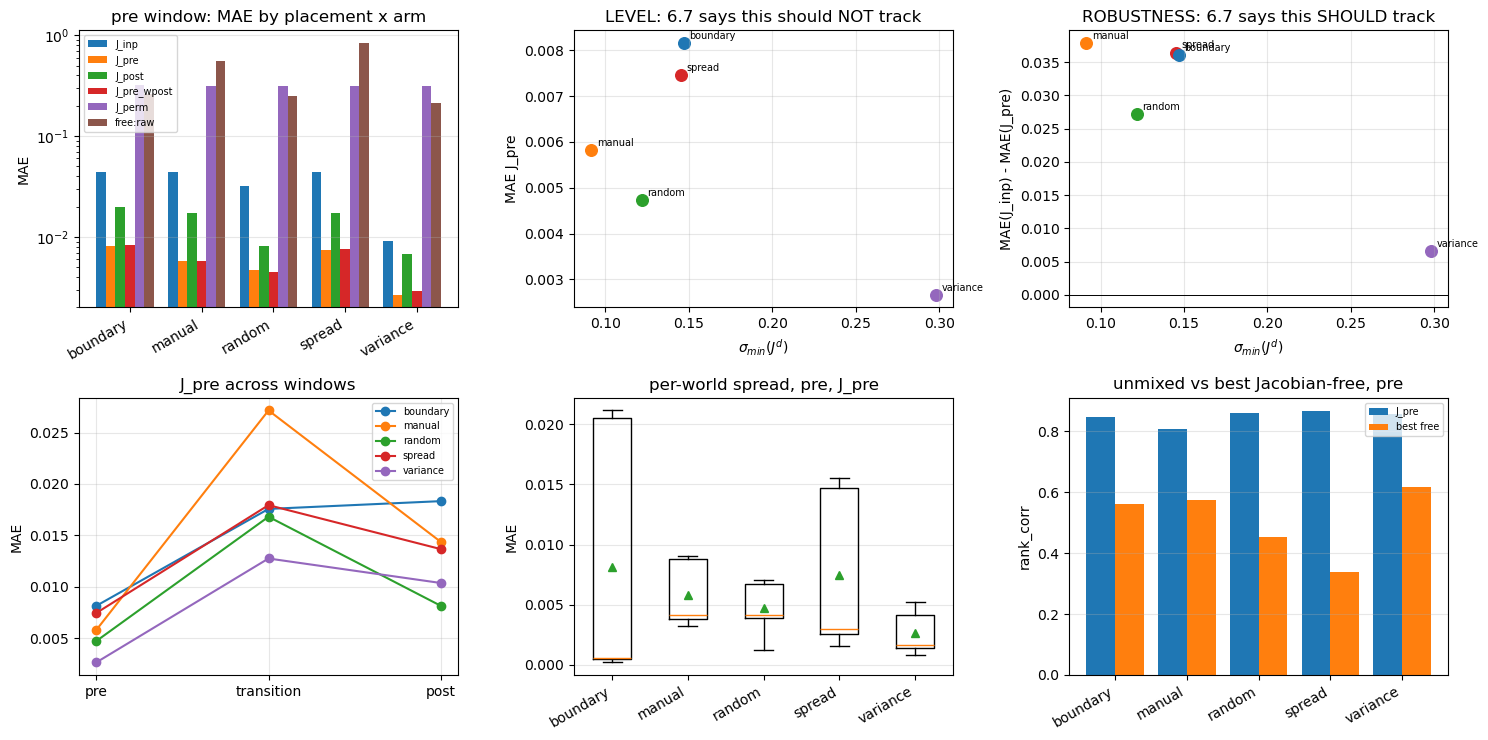

In [23]:
# --- placement visualisations --------------------------------------------
cols = dict(zip(pls, plt.cm.tab10.colors))
order = ["pre", "transition", "post"]
meth = [m for m in ARMS if m in set(R.method)] + ["free:raw"]
x = np.arange(len(pls))

fig, ax = plt.subplots(2, 3, figsize=(15, 7.5))

q = R[R.window == "pre"].pivot_table(index="placement", columns="method",
                                     values="mae").reindex(pls)
wdt = 0.8 / len(meth)
for k, m in enumerate(meth):
    if m in q.columns:
        ax[0, 0].bar(x + k * wdt, q[m].values, wdt, label=m)
ax[0, 0].set(xticks=x + 0.4, ylabel="MAE", yscale="log",
             title="pre window: MAE by placement x arm")
ax[0, 0].set_xticklabels(pls, rotation=30, ha="right")
ax[0, 0].legend(fontsize=7); ax[0, 0].grid(alpha=.3, axis="y")

T = PT.dropna(subset=["sigma_min"]) if "sigma_min" in PT.columns else PT.iloc[:0]
for _, r in T.iterrows():
    ax[0, 1].scatter(r.sigma_min, r[f"mae_{MAIN_ARM}"], s=70,
                     color=cols[r.placement])
    ax[0, 1].annotate(r.placement, (r.sigma_min, r[f"mae_{MAIN_ARM}"]),
                      fontsize=7, xytext=(4, 3), textcoords="offset points")
ax[0, 1].set(xlabel=r"$\sigma_{min}(J^d)$", ylabel=f"MAE {MAIN_ARM}",
             title="LEVEL: 6.7 says this should NOT track")
ax[0, 1].grid(alpha=.3)

if "misspec_penalty" in T.columns:
    for _, r in T.iterrows():
        ax[0, 2].scatter(r.sigma_min, r.misspec_penalty, s=70,
                         color=cols[r.placement])
        ax[0, 2].annotate(r.placement, (r.sigma_min, r.misspec_penalty),
                          fontsize=7, xytext=(4, 3), textcoords="offset points")
    ax[0, 2].axhline(0, color="k", lw=.7)
ax[0, 2].set(xlabel=r"$\sigma_{min}(J^d)$", ylabel="MAE(J_inp) - MAE(J_pre)",
             title="ROBUSTNESS: 6.7 says this SHOULD track")
ax[0, 2].grid(alpha=.3)

for pl in pls:
    sv = R[(R.placement == pl) & (R.method == MAIN_ARM)] \
        .groupby("window")["mae"].mean().reindex(order)
    ax[1, 0].plot(order, sv.values, "o-", color=cols[pl], label=pl)
ax[1, 0].set(ylabel="MAE", title=f"{MAIN_ARM} across windows")
ax[1, 0].legend(fontsize=7); ax[1, 0].grid(alpha=.3)

ax[1, 1].boxplot([R[(R.placement == pl) & (R.method == MAIN_ARM)
                    & (R.window == "pre")]["mae"].dropna().values
                  for pl in pls], showmeans=True)
ax[1, 1].set(ylabel="MAE", xticks=np.arange(1, len(pls) + 1),
             title=f"per-world spread, pre, {MAIN_ARM}")
ax[1, 1].set_xticklabels(pls, rotation=30, ha="right")
ax[1, 1].grid(alpha=.3, axis="y")

gg = G[G.window == "pre"].groupby("placement")[
    [MAIN_ARM, "best_free"]].mean().reindex(pls)
ax[1, 2].bar(x - .2, gg[MAIN_ARM].values, .4, label=MAIN_ARM)
ax[1, 2].bar(x + .2, gg["best_free"].values, .4, label="best free")
ax[1, 2].set(xticks=x, ylabel="rank_corr",
             title="unmixed vs best Jacobian-free, pre")
ax[1, 2].set_xticklabels(pls, rotation=30, ha="right")
ax[1, 2].axhline(0, color="k", lw=.7)
ax[1, 2].legend(fontsize=7); ax[1, 2].grid(alpha=.3, axis="y")

plt.tight_layout(); plt.show()

In [24]:
# --- does the placement ordering depend on WHICH measurand you ask? ------
inc0 = R[(R.arm_study == "income") & (R.window == "pre")]
if len(inc0):
    print("=== M2 (level) by placement, income arm ===")
    display(inc0.pivot_table(index="placement", columns="method",
                             values=["amp_rank_corr", "std_r"]).round(3))
print("=== gap retention by placement, pre window ===")
display(R[R.window == "pre"].pivot_table(index="placement", columns="method",
                                         values="gap_retention").round(3))
print("=== invariance null by placement (pure method error) ===")
display(pd.DataFrame([
    dict(placement=pl,
         invar_hat=J.delta_rho(PR, MAIN_ARM, pl)
                    .pipe(lambda d: d.loc[~d.involves_drifter, "d_hat"]
                          .abs().mean()),
         signed_hat=sign_hit(J.delta_rho(PR, MAIN_ARM, pl), "d_hat"))
    for pl in pls]).round(4))
print("M1 and M2 are orthogonal by construction, so a placement that recovers "
      "structure but not level would show up here and nowhere else.")

=== M2 (level) by placement, income arm ===


amp_rank_corr                                                                           std_r                                                                          
method            J_inp J_perm J_post J_pre J_pre_wpost free:pc1_removed free:raw free:robust_cm  J_inp J_perm J_post  J_pre J_pre_wpost free:pc1_removed free:raw free:robust_cm
placement                                                                                                                                                                        
boundary            1.0    0.6    1.0   1.0         1.0           -0.133      0.4         -0.133  0.004  0.736  0.002  0.001       0.002            0.928    0.722          0.927
manual              1.0    0.6    1.0   1.0         1.0           -0.500      0.1         -0.400  0.010  0.738  0.010  0.003       0.005            1.330    1.058          1.377
random              1.0    0.6    1.0   1.0         1.0           -0.200      0.3         -0.100  0.005  0.733  0.006  0.006       0.006            0.976    0.909          1.538
spread              1.0    0.6    1.0   1.0         1.0            0.467     -0.2          0.200  0.018  0.755  0.022  0.022       0.023            0.922    1.093          1.453
variance            1.0    0.6    1.0   1.0         1.0            0.600     -0.1          0.100  0.004  0.736  0.003  0.001       0.002            0.815    0.715          1.357

=== gap retention by placement, pre window ===


method,J_inp,J_perm,J_post,J_pre,J_pre_wpost,free:pc1_removed,free:raw,free:robust_cm
placement,,,,,,,,
boundary,1.043,-0.067,1.013,0.991,0.990,1.510,0.150,0.382
manual,1.023,-0.063,1.027,0.983,0.983,1.380,0.445,0.618
random,0.962,-0.069,1.003,0.997,0.997,1.452,0.501,0.976
spread,1.018,-0.067,0.994,0.987,0.986,0.127,0.286,-0.238
variance,0.982,-0.070,0.995,1.002,1.003,1.489,0.436,0.476


=== invariance null by placement (pure method error) ===


,placement,invar_hat,signed_hat
0,boundary,0.0114,1.0
1,manual,0.0101,1.0
2,random,0.0042,1.0
3,spread,0.0065,1.0
4,variance,0.0074,1.0


M1 and M2 are orthogonal by construction, so a placement that recovers structure but not level would show up here and nowhere else.


## 16. E12 — Does the estimator reproduce a known intervention?

**Question.** Does unmixing leave undisturbed district pairs undisturbed, and
does it recover the *signed* change that a known intervention causes?

**Why it is open.** Everything up to here is correlational: an estimate is
compared against a truth. These two properties are stronger, and S1 is the only
arm that has them.

*The invariance null.* When District D drifts, $\rho(A,B)$, $\rho(A,C)$ and
$\rho(B,C)$ are unchanged **by construction** — the four residential districts
are identical and only D moves. Any movement in the *estimated* value is
therefore pure method error, measured with no ground-truth ambiguity and
without needing a separate control world. It is also a direct test of whether
the inverse is actually isolating districts rather than smearing them.

*The signed prediction.* $\rho(D,E)$ must rise (D joins E's sector) and
$\rho(D,\{A,B,C\})$ must fall (D leaves theirs). Recovering the signed change
induced by a known intervention is a **causal** validation, not a correlational
one, and nothing in section 5 comes close to it.

**What decides it.** Pair-level, not aggregate: the estimand is per-pair
$\Delta\hat\rho$ between pre and post, with the predicted sign derived from
the state map on both sides of the drift. Scored against E4's empirical floor
and E4's truth-side ceiling, and reported with the effect size — a $\pm 0.72$
shift detected by an estimator with MAE $\ll 0.1$ is confirmation, not stress.

In [25]:
# =====================================================================
# E12. pair-level invariance and signed change
# =====================================================================
D = J.delta_rho(PR, method=MAIN_ARM, placement=PLACEMENT)
ANS = J.answer_pairs(D, FLOOR); LEDGER.extend(ANS); display(ANS)

,exp,question,metric,value,answer,basis
0,E12,Does the estimator leave undisturbed pairs undisturbed?,"mean |d rho_hat|, non-drifter pairs",0.0074,YES,floor 0.0200 taken from the truth in E4; truth moves 0.0012
1,E12,Does it recover the SIGNED change a known intervention causes?,"sign agreement, drifter pairs",1.0000,"YES -- causal, not correlational",ceiling from truth is 1.000; effect size |d rho_true| = 0.720


In [26]:
# --- sanity ---------------------------------------------------------------
display(D[D.predicted != 0].groupby("predicted")[["d_true", "d_hat"]]
        .agg(["mean", "std", "size"]).round(4))
display(pd.DataFrame([dict(
    arm=a, n=len(g),
    invar_hat=g.loc[~g.involves_drifter, "d_hat"].abs().mean(),
    invar_true=g.loc[~g.involves_drifter, "d_true"].abs().mean(),
    signed_hat=sign_hit(g, "d_hat"), signed_true=sign_hit(g, "d_true"))
    for a, g in D.groupby("arm_study")]).round(4))
print("worst individual pairs on the invariance null:")
display(D[~D.involves_drifter].nlargest(8, "d_hat")
        [["sim_hash", "arm_study", "a", "b", "d_true", "d_hat"]].round(4))

d_true                d_hat             
             mean     std size    mean     std size
predicted                                          
-1        -0.7201  0.0016   69 -0.6987  0.0424   69
 1         0.7202  0.0024   67  0.7205  0.0052   67

,arm,n,invar_hat,invar_true,signed_hat,signed_true
0,beta,30,0.0059,0.0012,1.0,1.0
1,coupling,40,0.0009,0.0007,1.0,1.0
2,income,60,0.0006,0.0004,NaN,NaN
3,s1_oddone,120,0.0049,0.0013,1.0,1.0
4,s2_split,150,0.0141,0.0016,1.0,1.0


worst individual pairs on the invariance null:


,sim_hash,arm_study,a,b,d_true,d_hat
397,3b72d3e3c8d0,s2_split,District_C,District_D,-0.0007,0.0877
297,195e0ab2cf6c,s2_split,District_C,District_D,0.0008,0.0836
347,472cb102f1c0,s2_split,District_C,District_D,-0.0034,0.0801
292,195e0ab2cf6c,s2_split,District_A,District_D,0.0057,0.0785
395,3b72d3e3c8d0,s2_split,District_B,District_D,0.0020,0.0772
295,195e0ab2cf6c,s2_split,District_B,District_D,0.0014,0.0739
392,3b72d3e3c8d0,s2_split,District_A,District_D,-0.0025,0.0733
342,472cb102f1c0,s2_split,District_A,District_D,-0.0040,0.0655


## 17. E13 — $\beta$: is the operating point the mechanism?

**Question.** *Why* does a Jacobian degrade across a regime change — because
the operating point moved, or because the within-district composition changed?

**Why it is open.** E8 measures *whether* `J_pre` survives and splits the
penalty into two terms, but a two-point split does not identify a mechanism.
$\beta$ dials the land-use **level** effect directly: at $\beta = 0$ the drift
is volume-neutral, so the operating point barely moves and the Jacobian should
hold — the control. At $\beta = 1$ the excursion is largest and the
$h \sim Q^{1.85}$ curvature that bounds local linearity should bite hardest.
Monotone degradation in $\beta$ would identify the operating point as the
cause; a flat curve would send the search to composition or conditioning
instead.

**What decides it, and what cannot.** Two constraints, both of which the
previous run violated.

1. **Match the cell.** The arm is one drift origin (District_D) at one seed
   (42), with $\beta$ the only thing allowed to vary. Aggregating every
   seed-42 world into the $0.35$ cell compares five drift districts against
   two single-world cells and means nothing.
2. **Check the reach first.** Only one district in five drifts, so the
   pre$\to$post excursion measured in E5 bounds what curvature has to act on
   regardless of $\beta$. If the excursion stays near $1$ across the ladder,
   the arm is underpowered *by construction* and a flat result is evidence
   about the dial, **not** evidence against the mechanism. Answering that
   question in the right order is the point of this section.

In [27]:
# =====================================================================
# E13. beta ladder, matched cell only
# =====================================================================
BCELL = WORLDS[(WORLDS.consumption_map == "LR_LR_LR_LR_LI")
               & (WORLDS.variant == "baseline")
               & (WORLDS.drift_district == "District_D")
               & (WORLDS.sim_seed == 42)]
b = R[R.sim_hash.isin(BCELL.sim_hash) & (R.placement == PLACEMENT)]

EX = pd.DataFrame()
if b.beta.nunique() >= 2:
    rows = []
    for _, w in BCELL.iterrows():
        art = P.load_world(w["dir"])
        dm = pd.read_parquet(pathlib.Path(w["dir"]) / J.PATHS["demand"])
        mk = J.window_masks(J.month_vector(art, dm, len(dm)))
        pre_t = J.op_from_window(dm, mk["pre"]).sum()
        post_t = J.op_from_window(dm, mk["post"]).sum()
        rows.append(dict(beta=w["beta"], sim_hash=w["sim_hash"],
                         pre_total=pre_t, post_total=post_t,
                         excursion=post_t / pre_t))
    EX = pd.DataFrame(rows).sort_values("beta")

ANS = J.answer_beta(b, EX, PLACEMENT, MAIN_ARM); LEDGER.extend(ANS)
display(ANS)

,exp,question,metric,value,answer,basis
0,E13,Does beta move the operating point enough to test the mechanism?,max post/pre demand ratio across the ladder,1.558573,YES,"threshold 1.1; only one district in five drifts, so the excursion is bounded regardless of beta"
1,E13,Is degradation monotone in beta?,MAE by beta,0.0:0.0022 / 0.35:0.0122 / 1.0:0.0041,no,"matched cell only (District_D, seed 42); a flat curve with no reach is evidence about the dial, not about the mechanism"


matched cell: 3 worlds, betas [0.0, 0.35, 1.0]


,sim_hash,beta,cell,studies
0,2f848af2d6ac,0.00,LR_LR_LR_LR_LI|baseline|b0.00|s42|Dli,beta
1,7c18c548fcc4,0.35,LR_LR_LR_LR_LI|baseline|b0.35|s42|Dli,"beta,s1_oddone"
3,4ffa4bda4b5c,1.00,LR_LR_LR_LR_LI|baseline|b1.00|s42|Dli,beta


,beta,sim_hash,pre_total,post_total,excursion
0,0.00,2f848af2d6ac,0.2838,0.2822,0.9943
1,0.35,7c18c548fcc4,0.2829,0.3364,1.1889
2,1.00,4ffa4bda4b5c,0.2813,0.4384,1.5586


window                   post     pre  transition
beta method                                      
0.00 J_inp             0.0021  0.0068      0.0241
     J_perm            0.2879  0.4306      0.3839
     J_post            0.0023  0.0036      0.0227
     J_pre             0.0022  0.0046      0.0208
     J_pre_wpost       0.0022  0.0028      0.0219
     free:pc1_removed  0.7471  1.0054      0.7742
     free:raw          0.1535  0.2500      0.1384
     free:robust_cm    0.6248  1.0057      0.7802
0.35 J_inp             0.0071  0.0126      0.0210
     J_perm            0.2995  0.4361      0.3868
     J_post            0.0008  0.0145      0.0167
     J_pre             0.0122  0.0052      0.0311
     J_pre_wpost       0.0121  0.0069      0.0317
     free:pc1_removed  0.7460  1.0338      0.7297
     free:raw          0.2050  0.1779      0.1644
     free:robust_cm    0.5759  0.9324      0.6238
1.00 J_inp             0.0618  0.0388      0.0899
     J_perm            0.2919  0.4323      0.4469
     J_post            0.0008  0.0179      0.0392
     J_pre             0.0041  0.0015      0.0516
     J_pre_wpost       0.0035  0.0016      0.0514
     free:pc1_removed  0.6886  1.0345      0.7016
     free:raw          0.8241  0.8752      0.8463
     free:robust_cm    0.8612  0.9672      0.7408

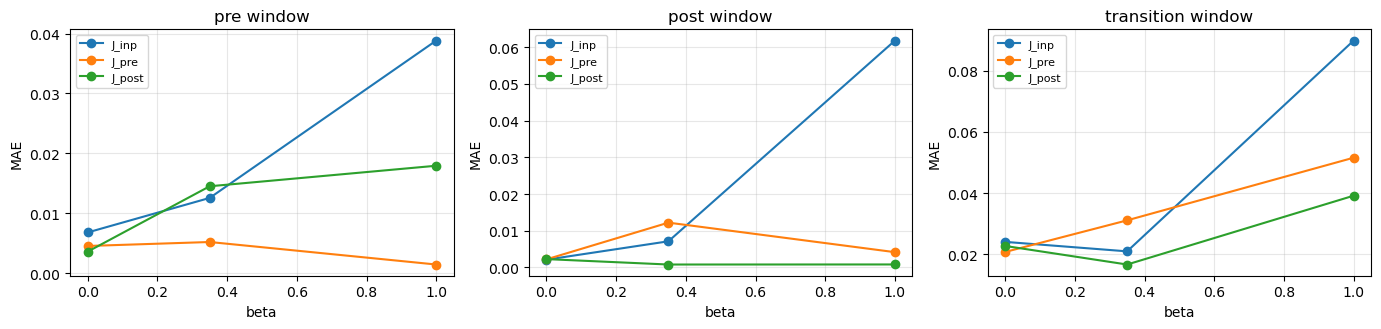

In [28]:
# --- sanity ---------------------------------------------------------------
print(f"matched cell: {len(BCELL)} worlds, betas {sorted(BCELL.beta.unique())}")
display(BCELL[["sim_hash", "beta", "cell", "studies"]])
if len(EX):
    display(EX.round(4))
if b.beta.nunique() >= 2:
    display(b.pivot_table(index=["beta", "method"], columns="window",
                          values="mae").round(4))
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
    for k, win in enumerate(["pre", "post", "transition"]):
        for m in ["J_inp", "J_pre", "J_post"]:
            sv = b[(b.method == m) & (b.window == win)] \
                .groupby("beta")["mae"].mean().sort_index()
            if len(sv):
                ax[k].plot(sv.index, sv.values, "o-", label=m)
        ax[k].set(xlabel="beta", ylabel="MAE", title=f"{win} window")
        ax[k].legend(fontsize=8); ax[k].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 18. E14 — The falsification: is the gain really hydraulic unmixing?

**Question.** When there is no inter-district mixing to undo, does the
advantage of unmixing disappear?

**Why it is open.** This is the load-bearing test in the suite. Section 5
attributes a large gain to inverting hydraulic mixing, and 6.5 already had to
withdraw a related claim ("78% of observed similarity is hydraulic mixing")
because a ratio of correlation coefficients does not decompose variance — four
pairs exceeded 100%. If the *mechanism* attribution is also wrong, the headline
survives as a number but not as an explanation, and an explanation is what
makes it a contribution rather than an empirical curiosity.

**What decides it.** With `close_fraction = 1.0` every inter-district boundary
is closed and each district gets its own reservoir, so mixing $\approx 0$ by
construction. The prediction: raw sensors should then **already** recover the
truth and unmixing should show near-zero gain. The baseline cells are exact
cache hits of `jval_s1_oddone` at seed 42, so the contrast is matched world for
world.

**And it is decomposed**, because a gain is a difference:

$$\text{gain} = \underbrace{q\big(\hat D^{\text{unmixed}}\big)}_{\text{term 1}} - \underbrace{\max_f q\big(\hat D^{f}\big)}_{\text{term 2}}.$$

Which term moves across the dial is the actual finding. If term 1 is flat while
term 2 collapses on isolated worlds, the **premise** failed, not the method: a
pipe is not a district-demand meter even with no inter-district mixing, because
it carries a routing-signed *subset* of its own district, and adding a
per-district reservoir changes that routing. The gain would then be
"pipe $\to$ district inversion", of which undoing inter-district mixing is only
one component — which narrows section 5's claim and gives 6.5 a second,
independent reason to be ill-posed.

In [29]:
# =====================================================================
# E14. baseline vs isolated, decomposed
# =====================================================================
CW = WORLDS[WORLDS.studies.str.contains("coupling")]
PAIRED = set(CW.sim_hash)
ANS = J.answer_coupling(G, PAIRED, PLACEMENT, MAIN_ARM)
LEDGER.extend(ANS); display(ANS)

,exp,question,metric,value,answer,basis
0,E14,Does the gain vanish when there is no mixing to undo?,gain: baseline -> isolated,+0.024 -> +0.873,NO,"n=2 baseline vs 2 isolated, paired cells only"
1,E14,Which term moved -- the estimator or the baseline?,delta(unmixed) / delta(best_free) across the dial,+0.079 / -0.770,"the BASELINE moved: P5's premise failed, not the method","a pipe is not a district-demand meter even without inter-district mixing -- it carries a routing-signed subset of its own district, and a per-dist..."
2,E14,So what is the gain attributable to?,interpretation,pipe->district inversion,broader than inter-district unmixing,"if the premise failed, section 5's attribution needs narrowing and 6.5 has a second reason to be ill-posed"


In [30]:
# --- sanity ---------------------------------------------------------------
display(CW[[c for c in ("sim_hash", "cell", "variant", "close_fraction",
                        "drift_district", "studies") if c in CW.columns]])
g = G[(G.window == "pre") & G.sim_hash.isin(PAIRED)
      & (G.placement == PLACEMENT)]
if len(g):
    display(g.pivot_table(index=["drift_district", "variant"],
                          values=[MAIN_ARM, "best_free", "gain"]).round(3))
    print("=== which free method, and on which variant ===")
    display(R[R.sim_hash.isin(PAIRED) & (R.window == "pre")
              & (R.placement == PLACEMENT)
              & R.method.str.startswith("free:")]
            .pivot_table(index="method", columns="variant",
                         values=["rank_corr", "mae"]).round(3))
    print("=== conditioning: does isolation change the inverse problem? ===")
    display(DG[DG.sim_hash.isin(PAIRED) & (DG.placement == PLACEMENT)]
            .merge(WORLDS[["sim_hash", "variant"]], on="sim_hash")
            .pivot_table(index="arm", columns="variant",
                         values=["sigma_min", "cond"]).round(4))

,sim_hash,cell,variant,close_fraction,drift_district,studies
4,74e5d158e6e7,LR_LR_LR_LR_LI|baseline|b0.35|s42|Ali,baseline,0.0,District_A,"coupling,s1_oddone"
5,adfe1b1ae73a,LR_LR_LR_LR_LI|baseline|b0.35|s42|Elr,baseline,0.0,District_E,"coupling,s1_oddone"
7,b472a1a6af0b,LR_LR_LR_LR_LI|isolated|b0.35|s42|Ali,isolated,1.0,District_A,coupling
8,adce256d7a30,LR_LR_LR_LR_LI|isolated|b0.35|s42|Elr,isolated,1.0,District_E,coupling


J_pre  best_free   gain
drift_district variant                          
District_A     baseline  0.806      0.782  0.024
               isolated  0.867     -0.079  0.945
District_E     baseline  0.806      0.782  0.024
               isolated  0.903      0.103  0.800

=== which free method, and on which variant ===


mae          rank_corr         
variant          baseline isolated  baseline isolated
method                                               
free:pc1_removed    1.034    0.900     0.733    0.012
free:raw            0.178    0.800     0.782   -0.200
free:robust_cm      0.932    0.608     0.212   -0.085

=== conditioning: does isolation change the inverse problem? ===


cond          sigma_min         
variant     baseline isolated  baseline isolated
arm                                             
J_inp         6.7809   2.8890    0.3021   0.2615
J_perm        7.1749   2.8761    0.2863   0.2621
J_post        6.9667   2.8839    0.2948   0.2619
J_pre         7.1749   2.8761    0.2863   0.2621
J_pre_wpost   7.1985   2.8865    0.2854   0.2617

## 19. E15 — The transition window is a prediction, not waste

**Question.** Does recovery degrade while a district is mid-conversion, and
return afterwards?

**Why it is open.** The forward model needs
$d_{i,t} = D_{k,t}\,w_{k,i}$ — within-district demand moving proportionally to
fixed shares. Mid-conversion that is exactly false: some nodes of the drifting
district have switched and others have not, so the district is internally
heterogeneous and $w_k$ is time-varying and spatially clustered. That is the
*spatially coherent* `node_weights` error which, in the misspecification tests,
was the only form of error that measurably hurt recovery — a BFS-concentrated
drift at weight error $0.097$ did more damage than isotropic error at $0.303$.

So the transition window is not thirty months of contaminated data to be
discarded. It is a place where the theory names a specific failure mode and
predicts its shape: error should rise while the front advances and fall once it
completes. Error tracking a known physical cause and then recovering is much
stronger evidence than a flat robustness number.

**What decides it.** Per-world ranking of the three windows on MAE, plus the
tie count — because mid-conversion the drifting district stops matching its
neighbours, `n_true_ties` falls, and Spearman becomes *more* informative there.
That can make `rank_corr` look best in the very window where MAE says recovery
is worst. Both are plotted so the artifact is visible rather than inferred.

In [31]:
# =====================================================================
# E15. windows
# =====================================================================
ANS = J.answer_windows(R, PLACEMENT, MAIN_ARM); LEDGER.extend(ANS); display(ANS)

,exp,question,metric,value,answer,basis
0,E15,Does recovery dip while a district is mid-conversion?,share of worlds where transition is worst on MAE,0.55,YES,"mid-conversion breaks the proportional-weights assumption, which is the spatially coherent node_weights error that was the only misspecification t..."
1,E15,Is the rank_corr window ordering trustworthy?,mean n_true_ties by window,pre:8.7 / transition:6.9 / post:9.9,no -- ties drive it,"ties drop mid-conversion, which inflates Spearman there even when MAE says recovery is worse; MAE is primary for this reason"


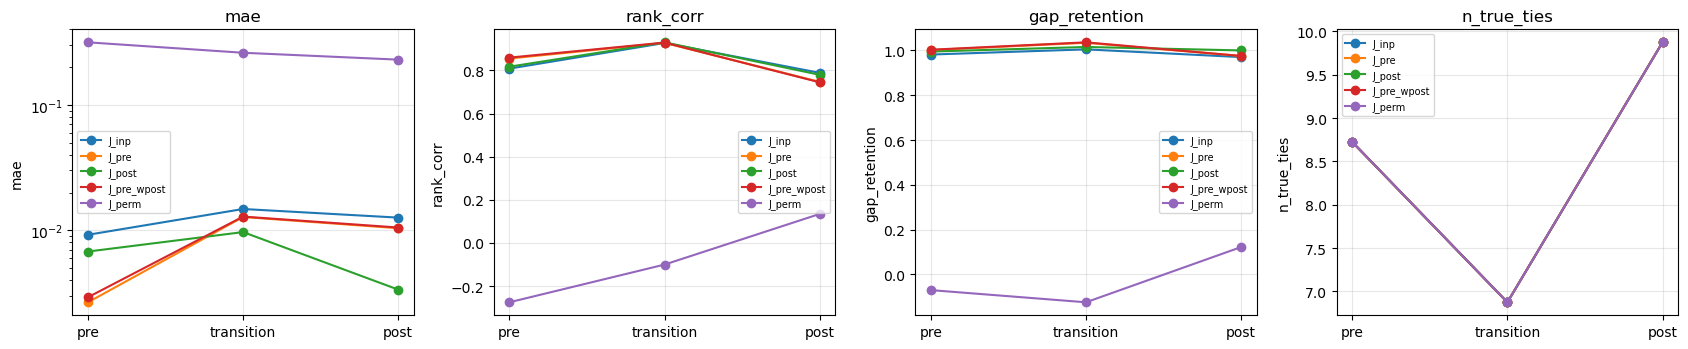

worst window per world:
transition    22
post          14
pre            4


window,pre,transition,post
count,40.0000,40.0000,40.0000
mean,0.0027,0.0128,0.0104
std,0.0016,0.0118,0.0108
min,0.0008,0.0013,0.0010
25%,0.0014,0.0038,0.0022
50%,0.0017,0.0082,0.0057
75%,0.0042,0.0216,0.0122
max,0.0052,0.0516,0.0357


In [32]:
# --- sanity ---------------------------------------------------------------
fig, ax = plt.subplots(1, 4, figsize=(17, 3.6))
for k, met in enumerate(["mae", "rank_corr", "gap_retention", "n_true_ties"]):
    for m in [a for a in ARMS if a in set(main.method)]:
        sv = main[main.method == m].groupby("window")[met].mean().reindex(order)
        ax[k].plot(order, sv.values, "o-", label=m)
    ax[k].set(title=met, ylabel=met); ax[k].grid(alpha=.3)
    if met == "mae":
        ax[k].set_yscale("log")
    ax[k].legend(fontsize=7)
plt.tight_layout(); plt.show()

piv2 = main[main.method == MAIN_ARM].pivot_table(
    index="sim_hash", columns="window", values="mae")[order]
print("worst window per world:"); print(piv2.idxmax(axis=1).value_counts().to_string())
display(piv2.describe().round(4))

## 20. E16 — The pre-registered scoreboard (7.8)

P1–P7 were written down before the numbers existed, precisely because a
post-hoc selection bug has already bitten once. Each verdict carries its
failure interpretation, so a FAIL is informative rather than merely
disappointing.

The second table repeats the entire scoreboard on every placement. A prediction
whose verdict flips with the sensor set is not a statement about the method,
and that is worth knowing before any of it is written up.

In [33]:
# =====================================================================
# E16. score P1..P7
# =====================================================================
SB = J.predictions(R, PR, main_arm=MAIN_ARM, placement=PLACEMENT,
                   noise_floor=FLOOR, paired_cells=PAIRED, excursion=EXC)
pd.set_option("display.max_colwidth", 400)
display(SB[["P", "claim", "value", "verdict"]])
for _, r in SB.iterrows():
    LEDGER.add("E16", f"{r.P}: {r.claim}", "pre-registered prediction",
               r.value, r.verdict, r.note)

print("=== verdict stability across placements ===")
display(pd.DataFrame([
    dict(placement=pl, **dict(zip(
        J.predictions(R, PR, main_arm=MAIN_ARM, placement=pl,
                      noise_floor=FLOOR, paired_cells=PAIRED,
                      excursion=EXC).P,
        J.predictions(R, PR, main_arm=MAIN_ARM, placement=pl,
                      noise_floor=FLOOR, paired_cells=PAIRED,
                      excursion=EXC).verdict)))
    for pl in pls]))

,P,claim,value,verdict
0,P1,pre-window MAE <= ~0.05,0.0027,PASS
1,P2,transition window worst of three,0.55,PASS
2,P3,|d rho_hat| non-drifter pairs < 0.0200,0.0074,PASS
3,P4,signed change correct in >=90%,1.0,PASS
4,P5,isolated gain ~ 0 while baseline gain > 0,iso +0.873 / base +0.024,FAIL
5,P6,MAE monotone increasing in beta,0.0:0.0022(n1) / 0.35:0.0122(n1) / 1.0:0.0041(n1),FAIL
6,P7,M2 amplitude rank correct,1.0,PASS


=== verdict stability across placements ===


,placement,P1,P2,P3,P4,P5,P6,P7
0,boundary,PASS,FAIL,PASS,PASS,FAIL,FAIL,PASS
1,manual,PASS,PASS,PASS,PASS,FAIL,FAIL,PASS
2,random,PASS,PASS,PASS,PASS,FAIL,FAIL,PASS
3,spread,PASS,PASS,PASS,PASS,PASS,FAIL,PASS
4,variance,PASS,PASS,PASS,PASS,FAIL,FAIL,PASS


In [34]:
# --- sanity: the full scoreboard with its failure interpretations --------
display(SB)

,P,claim,value,verdict,note
0,P1,pre-window MAE <= ~0.05,0.0027,PASS,"failure implicates the windowing, not the method. J_inp 0.0092 -> misspecification accounts for +0.0065 of it."
1,P2,transition window worst of three,0.55,PASS,"22/40 worlds; failure -> look at the operating point, not composition"
2,P3,|d rho_hat| non-drifter pairs < 0.0200,0.0074,PASS,n=240 pairs; true |d| = 0.0012
3,P4,signed change correct in >=90%,1.0,PASS,n=136 pairs; true-sign agreement 1.000
4,P5,isolated gain ~ 0 while baseline gain > 0,iso +0.873 / base +0.024,FAIL,"n=2v2. decomposition: unmixed moves +0.079, best_free moves -0.770 across the dial. If |free| >> |unmixed| the PREMISE failed, not the method: the gain is pipe->district inversion, of which inter-district unmixing is only one part."
5,P6,MAE monotone increasing in beta,0.0:0.0022(n1) / 0.35:0.0122(n1) / 1.0:0.0041(n1),FAIL,"excursion 1.295x pre-window demand. Below ~1.1x there is no operating-point movement for curvature to act on and the arm is underpowered BY CONSTRUCTION, whichever way it comes out -- a flat result is not evidence against the mechanism, it is evidence the dial has no reach here."
6,P7,M2 amplitude rank correct,1.0,PASS,n=6 income worlds; std_r=0.001. A negative answer to Q3 is still worth reporting.


## 21. E17 — Answer sheet

Every question this notebook asked, with the statistic it was decided on and
the rule that decided it. This is the section to read; everything above is the
derivation. `basis` carries the threshold or the caveat, so a verdict can be
traced without re-running anything.

In [35]:
# =====================================================================
# E17. the answer sheet
# =====================================================================
SHEET = LEDGER.frame()
display(SHEET[SHEET.exp != "E16"][["exp", "question", "metric", "value",
                                   "answer"]])
print("=== pre-registered predictions ===")
display(SHEET[SHEET.exp == "E16"][["question", "value", "answer"]])
print("\n=== with the deciding rule ===")
display(SHEET[["exp", "question", "answer", "basis"]])

,exp,question,metric,value,answer
0,E1,"Did we build the design, and only the design?",studies complete / total,3/5,NO -- arms incomplete
1,E1,How many 48-month worlds are foreign to the design?,unmatched + duplicate-cell,1 + 4,5 excluded
2,E1,How many worlds carry the analysis?,pinned,40,"40 worlds, 5 arms"
3,E2,Did every world's drift front complete inside the horizon?,worlds failing the 7.7 gate,0,YES -- all pass
4,E3,Are the pre and post windows comparable?,equal length AND same calendar months,"4320 / 4320, 36 mod 12 = 0",YES
5,E4,Is the invariance null clean enough in the TRUTH to score P3?,"mean |d rho_true|, non-drifter pairs",0.001198,YES
6,E4,Does the intervention move the truth in the predicted direction?,sign agreement in truth (P4 ceiling),1.0,YES
7,E4,How demanding is the gap test?,effect size |d rho_true|,0.720128,large
8,E5,Is the .inp-anchored probe point feasible?,inp_base total / pre-window total,0.982,YES
9,E5,How far does the operating point move across the drift?,post/pre total demand,1.295,material


=== pre-registered predictions ===


,question,value,answer
35,P1: pre-window MAE <= ~0.05,0.0027,PASS
36,P2: transition window worst of three,0.55,PASS
37,P3: |d rho_hat| non-drifter pairs < 0.0200,0.0074,PASS
38,P4: signed change correct in >=90%,1.0,PASS
39,P5: isolated gain ~ 0 while baseline gain > 0,iso +0.873 / base +0.024,FAIL
40,P6: MAE monotone increasing in beta,0.0:0.0022(n1) / 0.35:0.0122(n1) / 1.0:0.0041(n1),FAIL
41,P7: M2 amplitude rank correct,1.0,PASS



=== with the deciding rule ===


,exp,question,answer,basis
0,E1,"Did we build the design, and only the design?",NO -- arms incomplete,design_table() cell-by-cell match
1,E1,How many 48-month worlds are foreign to the design?,5 excluded,arm=='other' or dup=True; rule-based labelling had swept these in
2,E1,How many worlds carry the analysis?,"40 worlds, 5 arms",gate 7.7 passed AND design-matched AND not duplicate
3,E2,Did every world's drift front complete inside the horizon?,YES -- all pass,front_complete AND clears_post AND pre_clean
4,E3,Are the pre and post windows comparable?,YES,equal variance for the two estimators; seasonal cycle cancels
5,E4,Is the invariance null clean enough in the TRUTH to score P3?,YES,threshold 0.02; P3 floor set to 0.0200
6,E4,Does the intervention move the truth in the predicted direction?,YES,ceiling for P4; threshold 0.9
7,E4,How demanding is the gap test?,large,"sd(G_true) across worlds = 0.0012; near-zero means G is an almost deterministic function of the land-use token, so passing the gap test is cheap"
8,E5,Is the .inp-anchored probe point feasible?,YES,anchor_scale=0.05; a ratio near 1/0.05 means flat_baseline's default of 1.0 was used
9,E5,How far does the operating point move across the drift?,material,"threshold 1.1; bounds what h~Q^1.85 curvature has to act on, and therefore bounds E15"


## 22. Export

Everything a thesis table needs, reconstructible from `pinned_worlds.csv` plus
`answer_sheet.csv`.

In [36]:
# =====================================================================
# 22. persist
# =====================================================================
# the ledger's `value` column is deliberately mixed-type (floats, ratios,
# formatted pairs), so it goes to CSV only -- parquet needs one type per column
files = J.save(OUT, results=R, pairs=PR, truth=TA, jacobian_diag=DG,
               gain_rank=G, gain_mae=GM, placement_table=PT)
for name, df in (("gates", GATES), ("arm_labels", LAB),
                 ("design_audit", J.design_audit(LAB)), ("scoreboard", SB),
                 ("probe_diag", PD), ("answer_sheet", SHEET),
                 ("beta_excursion", EX), ("skipped_worlds", SKIPPED)):
    if isinstance(df, pd.DataFrame) and len(df):
        df.to_csv(OUT / f"{name}.csv", index=False)
print(sorted(p.name for p in OUT.glob("*")))
print(f"-> {OUT}")

['answer_sheet.csv', 'arm_labels.csv', 'beta_excursion.csv', 'design_audit.csv', 'gain_mae.parquet', 'gain_rank.parquet', 'gates.csv', 'jacobian_diag.parquet', 'pairs.parquet', 'pinned_worlds.csv', 'placement_table.parquet', 'probe_cache.pkl', 'probe_diag.csv', 'results.parquet', 'scoreboard.csv', 'truth.parquet']
-> C:\Users\arthu\USPy\10_Mestrado\fedWater\data\08_reporting\jval
